In [1]:
import mlflow

# Point MLflow to your local UI server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# Create and set our main experiment
mlflow.set_experiment("FITE_Classification_Challenge")

c:\Users\Ali Sliman\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/07/01 17:21:47 INFO mlflow.tracking.fluent: Experiment with name 'FITE_Classification_Challenge' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1782915708015, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782915708015, lifecycle_stage='active', name='FITE_Classification_Challenge', tags={}, trace_location=None, workspace='default'>

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
DATA_DIR = Path(".")

TRAIN_PATH = DATA_DIR / "train_data.csv"
TEST_PATH = DATA_DIR / "test_data.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

ID_COL = "ID"
TARGET_COL = "target"

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTarget distribution:")
print(train_df[TARGET_COL].value_counts())

print("\nTarget distribution %:")
print((train_df[TARGET_COL].value_counts(normalize=True) * 100).round(2))

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

Train shape: (3200, 23)
Test shape: (3200, 22)

Target distribution:
target
class3    2916
class2     191
class1      93
Name: count, dtype: int64

Target distribution %:
target
class3    91.12
class2     5.97
class1     2.91
Name: proportion, dtype: float64

Sample submission columns:
['ID', 'target']


Feature Importance Analysis
All features count: 21
Selected features count: 8
Dropped features count: 13

Selected features:
['f1', 'f2', 'f9', 'f10', 'f12', 'f14', 'f17', 'f20']

Dropped features:
['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f13', 'f15', 'f16', 'f18', 'f19', 'f21']

Feature importance table:


,importance_rank,feature,importance,decision,note
0,1,f14,2437,Selected,Used by model
1,2,f9,2322,Selected,Used by model
2,3,f10,1882,Selected,Used by model
3,4,f1,1817,Selected,Used by model
4,5,f2,1710,Selected,Used by model
5,6,f20,1312,Selected,Used by model
6,7,f17,784,Selected,Used by model
7,8,f12,671,Selected,Used by model
8,9,f18,72,Dropped,Used by model
9,10,f13,51,Dropped,Used by model



Zero importance features:


,feature,importance,decision
12,f3,0,Dropped
13,f5,0,Dropped
14,f11,0,Dropped
15,f7,0,Dropped
16,f6,0,Dropped
17,f16,0,Dropped
18,f15,0,Dropped
19,f19,0,Dropped
20,f21,0,Dropped



Lowest importance features:


,feature,importance,decision
12,f3,0,Dropped
13,f5,0,Dropped
14,f11,0,Dropped
15,f7,0,Dropped
16,f6,0,Dropped
17,f16,0,Dropped
18,f15,0,Dropped
19,f19,0,Dropped
20,f21,0,Dropped


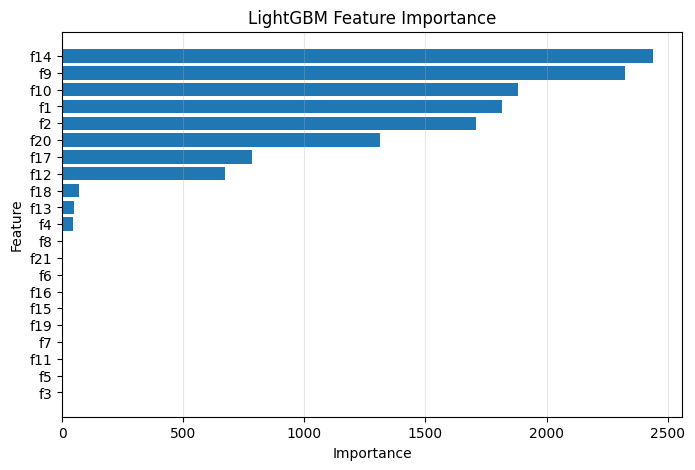

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from IPython.display import display

if "train_df" not in globals():
    train_df = pd.read_csv("train_data.csv")

ID_COL = "ID"
TARGET_COL = "target"

ALL_FEATURES = [
    col for col in train_df.columns
    if col not in [ID_COL, TARGET_COL]
]

SELECTED8 = ["f1", "f2", "f9", "f10", "f12", "f14", "f17", "f20"]

DROPPED_FEATURES = [
    col for col in ALL_FEATURES
    if col not in SELECTED8
]

X_all = train_df[ALL_FEATURES]
y = train_df[TARGET_COL]

model_params = {
    "n_estimators": 500,
    "learning_rate": 0.04,
    "num_leaves": 22,
    "max_depth": 5,
    "min_child_samples": 12,
    "objective": "multiclass",
    "random_state": 42,
    "verbosity": -1,
    "n_jobs": -1
}

print("Feature Importance Analysis")

print("All features count:", len(ALL_FEATURES))
print("Selected features count:", len(SELECTED8))
print("Dropped features count:", len(DROPPED_FEATURES))

print("\nSelected features:")
print(SELECTED8)

print("\nDropped features:")
print(DROPPED_FEATURES)

importance_model = LGBMClassifier(**model_params)
importance_model.fit(X_all, y)

importance_df = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance": importance_model.feature_importances_,
    "selected_in_final_features": [
        feature in SELECTED8 for feature in ALL_FEATURES
    ]
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df["importance_rank"] = importance_df.index + 1

importance_df["decision"] = importance_df["selected_in_final_features"].map({
    True: "Selected",
    False: "Dropped"
})

importance_df["note"] = importance_df["importance"].apply(
    lambda x: "Zero importance" if x == 0 else "Used by model"
)

print("\nFeature importance table:")
display(
    importance_df[
        [
            "importance_rank",
            "feature",
            "importance",
            "decision",
            "note"
        ]
    ]
)

zero_importance_df = importance_df[importance_df["importance"] == 0].copy()
low_importance_df = importance_df[importance_df["importance"] <= importance_df["importance"].quantile(0.25)].copy()

print("\nZero importance features:")
display(zero_importance_df[["feature", "importance", "decision"]])

print("\nLowest importance features:")
display(low_importance_df[["feature", "importance", "decision"]])

plt.figure(figsize=(8, 5))
plot_df = importance_df.sort_values("importance", ascending=True)

plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


هذه الخلية تحدد الأعمدة المستخدمة في التدريب.  
هنا اعتمدنا مجموعة ⁦SELECTED8⁩ لأنها كانت أكثر الأعمدة فائدة وثباتاً في التجارب: ⁦f1⁩ و⁦f2⁩ و⁦f9⁩ و⁦f10⁩ و⁦f12⁩ و⁦f14⁩ و⁦f17⁩ و⁦f20⁩.


In [4]:
DROP_COLS = [
    "f19", "f7", "f16", "f21",
    "f3", "f5", "f6", "f8", "f11", "f15",
    "f13", "f4", "f18"
]

ALL_FEATURES = [
    col for col in train_df.columns
    if col not in [ID_COL, TARGET_COL]
]

SELECTED_FEATURES = [
    col for col in ALL_FEATURES
    if col not in DROP_COLS
]

print("All features:", len(ALL_FEATURES))
print("Dropped features:", len(DROP_COLS))
print("Selected features:", len(SELECTED_FEATURES))
print("\nSelected features:")
print(SELECTED_FEATURES)

missing_cols = [c for c in SELECTED_FEATURES if c not in test_df.columns]
assert len(missing_cols) == 0, f"Missing columns in test: {missing_cols}"

All features: 21
Dropped features: 13
Selected features: 8

Selected features:
['f1', 'f2', 'f9', 'f10', 'f12', 'f14', 'f17', 'f20']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

if "train_df" not in globals():
    train_df = pd.read_csv("train_data.csv")

if "TARGET_COL" not in globals():
    TARGET_COL = "target"

if "ID_COL" not in globals():
    ID_COL = "ID"

# print("=" * 90)
# print("تحليل بسيط لفكرة حذف الصفوف المشبوهة من class3")
# print("=" * 90)

# print("""
# الفكرة:
# نريد فحص صفوف target = class3 التي تملك قيمة f10 مرتفعة بشكل غير طبيعي.
# لكن لا نحذف مباشرة اعتماداً على f10 فقط.
# لذلك نستخدم f9 و f14 كشرط حماية، ونأخذ حد q95 لهما داخل class3.
# """)

# 1) ملخص f10 حسب كل فئة
f10_summary = (
    train_df
    .groupby(TARGET_COL)["f10"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        q90=lambda x: x.quantile(0.90),
        q95=lambda x: x.quantile(0.95),
        max="max"
    )
    .reset_index()
)

print("\n1) توزيع f10 حسب كل class:")
display(f10_summary)

# # 2) مخطط بسيط لتوزيع f10 حسب الفئة
# plt.figure(figsize=(7, 4))

# classes = sorted(train_df[TARGET_COL].unique())

# plt.boxplot(
#     [train_df.loc[train_df[TARGET_COL] == cls, "f10"] for cls in classes],
#     labels=classes,
#     showfliers=True
# )

# plt.axhline(0.02, linestyle="--")
# plt.title("f10 distribution by class")
# plt.xlabel("class")
# plt.ylabel("f10")
# plt.grid(True, alpha=0.3)
# plt.show()


# 3) حساب حدود q95 داخل class3
class3_mask = train_df[TARGET_COL] == "class3"

class3_f9_q95 = train_df.loc[class3_mask, "f9"].quantile(0.95)
class3_f14_q95 = train_df.loc[class3_mask, "f14"].quantile(0.95)

print("\n2) حدود q95 داخل class3:")
print("class3 f9  q95 =", class3_f9_q95)
print("class3 f14 q95 =", class3_f14_q95)


# 4) تطبيق نفس شروط اكتشاف الصفوف المشبوهة
high_f10_mask = train_df["f10"] > 0.02

normal_f9_f14_mask = (
    (train_df["f9"] <= class3_f9_q95) &
    (train_df["f14"] <= class3_f14_q95)
)

noisy_candidate_mask = class3_mask & high_f10_mask & normal_f9_f14_mask

noisy_candidates = train_df.loc[noisy_candidate_mask].copy()

# print("Detected noisy candidate rows:", len(noisy_candidates))
# print("Total train rows:", len(train_df))
# print("Ratio from train:", round(len(noisy_candidates) / len(train_df), 5))

display(
    noisy_candidates[
        [ID_COL, TARGET_COL, "f10", "f9", "f14", "f2", "f1", "f20"]
    ].sort_values("f10", ascending=False)
)



1) توزيع f10 حسب كل class:


,target,count,mean,median,q90,q95,max
0,class1,93,0.093412,0.05100,0.1870,0.4160,0.530
1,class2,191,0.013952,0.00979,0.0264,0.0350,0.143
2,class3,2916,0.001774,0.00140,0.0033,0.0046,0.145



2) حدود q95 داخل class3:
class3 f9  q95 = 0.17
class3 f14 q95 = 0.165
Detected noisy candidate rows: 14
Total train rows: 3200
Ratio from train: 0.00438


,ID,target,f10,f9,f14,f2,f1,f20
1871,1872,class3,0.145,0.036,0.0240,0.0120,0.17,0.150
1449,1450,class3,0.078,0.078,0.0670,0.0206,0.53,0.116
1369,1370,class3,0.036,0.162,0.1420,0.0450,0.25,0.115
2843,2844,class3,0.032,0.085,0.0710,0.0140,0.64,0.116
1556,1557,class3,0.030,0.030,0.0210,0.0120,0.16,0.145
1377,1378,class3,0.028,0.074,0.0720,0.0206,0.74,0.103
645,646,class3,0.028,0.086,0.0870,0.0200,0.17,0.099
1287,1288,class3,0.027,0.087,0.0877,0.0170,0.37,0.099
2140,2141,class3,0.026,0.107,0.0880,0.0370,0.34,0.121
1818,1819,class3,0.026,0.073,0.0720,0.0206,0.84,0.103


هذه الخلية تبني قاعدة محافظة لاكتشاف بعض صفوف ⁦class3⁩ المشبوهة.  
الفكرة أن بعض صفوف ⁦class3⁩ كان عندها ⁦f10⁩ مرتفع بطريقة لا تشبه أغلب ⁦class3⁩، لذلك عرضنا هذه الصفوف قبل اتخاذ قرار التنظيف.


In [ ]:
def detect_noisy_class3_rows(df):
    class3_mask = df[TARGET_COL] == "class3"

    high_f10_mask = df["f10"] > 0.02

    class3_f9_q95 = df.loc[class3_mask, "f9"].quantile(0.95)
    class3_f14_q95 = df.loc[class3_mask, "f14"].quantile(0.95)

    normal_f9_f14_mask = (
        (df["f9"] <= class3_f9_q95) &
        (df["f14"] <= class3_f14_q95)
    )

    noisy_mask = class3_mask & high_f10_mask & normal_f9_f14_mask

    return noisy_mask


noisy_mask = detect_noisy_class3_rows(train_df)
noisy_rows = train_df.loc[noisy_mask].copy()

print("Detected noisy candidate rows:", len(noisy_rows))

display(
    noisy_rows[
        [ID_COL, TARGET_COL, "f10", "f9", "f14", "f2", "f1", "f20"]
    ].sort_values("f10", ascending=False)
)

Detected noisy candidate rows: 14


,ID,target,f10,f9,f14,f2,f1,f20
1871,1872,class3,0.145,0.036,0.0240,0.0120,0.17,0.150
1449,1450,class3,0.078,0.078,0.0670,0.0206,0.53,0.116
1369,1370,class3,0.036,0.162,0.1420,0.0450,0.25,0.115
2843,2844,class3,0.032,0.085,0.0710,0.0140,0.64,0.116
1556,1557,class3,0.030,0.030,0.0210,0.0120,0.16,0.145
1377,1378,class3,0.028,0.074,0.0720,0.0206,0.74,0.103
645,646,class3,0.028,0.086,0.0870,0.0200,0.17,0.099
1287,1288,class3,0.027,0.087,0.0877,0.0170,0.37,0.099
2140,2141,class3,0.026,0.107,0.0880,0.0370,0.34,0.121
1818,1819,class3,0.026,0.073,0.0720,0.0206,0.84,0.103


هذه الخلية تنشئ نسختين من التدريب: نسخة كاملة ونسخة منظفة بعد حذف الصفوف المشبوهة.  
الخرج يوضح أننا حذفنا ⁦14⁩ صفاً فقط من ⁦class3⁩، أي أن التنظيف كان محافظاً وليس عدوانياً.


In [6]:
train_keep = train_df.copy()
train_clean = train_df.loc[~noisy_mask].copy()

print("Original train shape:", train_keep.shape)
print("Cleaned train shape:", train_clean.shape)
print("Removed rows:", len(train_keep) - len(train_clean))

print("\nOriginal target distribution:")
print(train_keep[TARGET_COL].value_counts())

print("\nCleaned target distribution:")
print(train_clean[TARGET_COL].value_counts())

Original train shape: (3200, 23)
Cleaned train shape: (3186, 23)
Removed rows: 14

Original target distribution:
target
class3    2916
class2     191
class1      93
Name: count, dtype: int64

Cleaned target distribution:
target
class3    2902
class2     191
class1      93
Name: count, dtype: int64


هذه الخلية تعرف طريقة بسيطة لحساب أوزان الفئات.  
استخدمناها لاحقاً لاختبار هل الأوزان تساعد الفئات الصغيرة أم أنها تزيد أخطاء ⁦class3⁩.


In [7]:
ALPHA = 0.10
MAX_WEIGHT = 2.0
MIN_WEIGHT = 1.0

def make_clipped_alpha_weights(y_values, alpha=0.10, max_weight=2.0, min_weight=1.0):
    counts = y_values.value_counts()
    max_count = counts.max()

    weights = {}
    for cls, count in counts.items():
        raw_weight = (max_count / count) ** alpha
        clipped_weight = np.clip(raw_weight, min_weight, max_weight)
        weights[cls] = float(clipped_weight)

    return dict(sorted(weights.items()))


print("Weights on original train:")
print(make_clipped_alpha_weights(train_keep[TARGET_COL], ALPHA, MAX_WEIGHT, MIN_WEIGHT))

print("\nWeights on cleaned train:")
print(make_clipped_alpha_weights(train_clean[TARGET_COL], ALPHA, MAX_WEIGHT, MIN_WEIGHT))

Weights on original train:
{'class1': 1.4113361220643739, 'class2': 1.3133346885186488, 'class3': 1.0}

Weights on cleaned train:
{'class1': 1.4106570574372468, 'class2': 1.3127027772987705, 'class3': 1.0}


هذه الخلية تضبط إعدادات ⁦LightGBM⁩ الأساسية وتعرف دوال بناء الموديل والتقييم.  
هذه الإعدادات كانت نقطة البداية قبل تحسين الحدود بالـ ⁦logits⁩.


In [8]:
BEST_PARAMS = {
    "n_estimators": 900,
    "learning_rate": 0.015,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 15,
    "subsample": 0.90,
    "subsample_freq": 1,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.05,
    "reg_lambda": 3.0,
}

def build_lgbm(random_state=42):
    return LGBMClassifier(
        objective="multiclass",
        **BEST_PARAMS,
        random_state=random_state,
        n_jobs=-1,
        verbosity=-1
    )

هذه الخلية تعرف دالة تشغيل تجربة ⁦OOF⁩ كاملة.  
الدالة تدرب النموذج على ⁦folds⁩، تجمع احتمالات التنبؤ، ثم ترجع المقاييس والتوقعات، وهذا جعل مقارنة التجارب عادلة ومنظمة.


In [9]:
def run_oof_experiment(
    train_data,
    feature_cols,
    experiment_name,
    use_weights=False,
    n_splits=5,
    random_state=42
):
    X = train_data[feature_cols].copy()
    y = train_data[TARGET_COL].copy()
    labels = sorted(y.unique())

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    oof_pred = pd.Series(index=train_data.index, dtype="object")
    oof_proba = pd.DataFrame(
        0.0,
        index=train_data.index,
        columns=labels
    )

    fold_rows = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_train = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]
        y_train = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        model = build_lgbm(random_state=random_state + fold)

        if use_weights:
            class_weights = make_clipped_alpha_weights(
                y_train,
                alpha=ALPHA,
                max_weight=MAX_WEIGHT,
                min_weight=MIN_WEIGHT
            )
            sample_weights = y_train.map(class_weights).astype(float)

            model.fit(
                X_train,
                y_train,
                sample_weight=sample_weights
            )
        else:
            model.fit(X_train, y_train)

        proba = model.predict_proba(X_val)
        proba_df = pd.DataFrame(
            proba,
            columns=model.classes_,
            index=X_val.index
        )[labels]

        pred = proba_df.idxmax(axis=1)

        oof_pred.iloc[val_idx] = pred
        oof_proba.iloc[val_idx] = proba_df

        fold_rows.append({
            "experiment": experiment_name,
            "fold": fold,
            "accuracy": accuracy_score(y_val, pred),
            "balanced_accuracy": balanced_accuracy_score(y_val, pred),
            "f1_macro": f1_score(y_val, pred, average="macro", zero_division=0),
            "wrong_count": int((pred.values != y_val.values).sum())
        })

    metrics = {
        "experiment": experiment_name,
        "n_rows": len(train_data),
        "n_features": len(feature_cols),
        "use_weights": use_weights,
        "accuracy": accuracy_score(y, oof_pred),
        "balanced_accuracy": balanced_accuracy_score(y, oof_pred),
        "precision_macro": precision_score(y, oof_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y, oof_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y, oof_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y, oof_pred, average="weighted", zero_division=0),
        "wrong_count": int((oof_pred.values != y.values).sum())
    }

    return metrics, pd.DataFrame(fold_rows), oof_pred, oof_proba

# 2. مقارنة موديلات مختلفة واختيار ⁦LightGBM⁩

قبل أن نكمل تحسين ⁦LightGBM⁩، جربنا أكثر من موديل حتى لا يكون اختيارنا عشوائياً.  
هنا نقارن بين:

```text
LightGBM
RandomForest
ExtraTrees
LogisticRegression
KNN
```

استخدمنا نفس الداتا المنظفة ونفس ⁦SELECTED8⁩ في كل الموديلات حتى تكون المقارنة عادلة.  
الهدف من هذه التجربة ليس فقط معرفة أعلى رقم، بل معرفة أي موديل يعطي أفضل توازن بين ⁦macro F1⁩، وعدد الأخطاء، ومصفوفة الارتباك.

هذه الخلية تستورد الموديلات الثانية التي سنقارنها مع ⁦LightGBM⁩.  
استخدمنا ⁦StandardScaler⁩ مع ⁦LogisticRegression⁩ و⁦KNN⁩ لأن هذين الموديلين يتأثران بمقياس الميزات.

In [10]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

MODEL_COMPARE_DATA = train_clean.copy()
MODEL_COMPARE_FEATURES = SELECTED_FEATURES.copy()

X_model_compare = MODEL_COMPARE_DATA[MODEL_COMPARE_FEATURES].copy()
y_model_compare = MODEL_COMPARE_DATA[TARGET_COL].copy()
compare_labels = sorted(y_model_compare.unique())

print("Data used for model comparison:", X_model_compare.shape)
print("Labels:", compare_labels)
print("Features:", MODEL_COMPARE_FEATURES)

Data used for model comparison: (3186, 8)
Labels: ['class1', 'class2', 'class3']
Features: ['f1', 'f2', 'f9', 'f10', 'f12', 'f14', 'f17', 'f20']


هذه الخلية تعرف دالة عامة لتشغيل ⁦OOF validation⁩ لأي موديل.  
الدالة ترجع التوقعات خارج الطية، ثم نحسب عليها ⁦macro F1⁩ و⁦wrong_count⁩ ونرسم ⁦confusion matrix⁩ لكل موديل.

In [11]:
def run_oof_for_any_model(model_builder, X_data, y_data, labels, n_splits=5, random_state=42):
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    oof_pred = pd.Series(index=y_data.index, dtype="object")

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_data, y_data), 1):
        X_train = X_data.iloc[tr_idx]
        X_val = X_data.iloc[val_idx]
        y_train = y_data.iloc[tr_idx]

        model = model_builder(random_state + fold)
        model.fit(X_train, y_train)

        pred = model.predict(X_val)
        oof_pred.iloc[val_idx] = pred

    metrics = {
        "accuracy": accuracy_score(y_data, oof_pred),
        "balanced_accuracy": balanced_accuracy_score(y_data, oof_pred),
        "precision_macro": precision_score(y_data, oof_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_data, oof_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_data, oof_pred, average="macro", zero_division=0),
        "wrong_count": int((oof_pred.values != y_data.values).sum())
    }

    cm = pd.DataFrame(
        confusion_matrix(y_data, oof_pred, labels=labels),
        index=[f"true_{c}" for c in labels],
        columns=[f"pred_{c}" for c in labels]
    )

    return metrics, oof_pred, cm

هذه الخلية تشغل المقارنة الفعلية بين الموديلات الخمسة.  
لاحظ أننا لا نغير الداتا بين موديل وآخر، حتى يكون الفرق من الموديل نفسه وليس من تجهيز مختلف للبيانات.

In [12]:
def build_random_forest(random_state=42):
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=9,
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1
    )


def build_extra_trees_compare(random_state=42):
    return ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1
    )


def build_logistic_regression(random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            C=1.0,
            random_state=random_state
        ))
    ])


def build_knn_compare(random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=7,
            weights="distance",
            metric="euclidean"
        ))
    ])


MODEL_BUILDERS = {
    "LightGBM": build_lgbm,
    "RandomForest": build_random_forest,
    "ExtraTrees": build_extra_trees_compare,
    "LogisticRegression": build_logistic_regression,
    "KNN": build_knn_compare
}

model_comparison_rows = []
model_comparison_preds = {}
model_comparison_cms = {}

for model_name, builder in MODEL_BUILDERS.items():
    print("=" * 90)
    print("Training and evaluating:", model_name)

    metrics, oof_pred, cm_df = run_oof_for_any_model(
        model_builder=builder,
        X_data=X_model_compare,
        y_data=y_model_compare,
        labels=compare_labels,
        n_splits=5,
        random_state=42
    )

    metrics["model"] = model_name
    model_comparison_rows.append(metrics)
    model_comparison_preds[model_name] = oof_pred
    model_comparison_cms[model_name] = cm_df

    print("\nClassification report:")
    print(classification_report(
        y_model_compare,
        oof_pred,
        digits=4,
        zero_division=0
    ))

    print("Confusion matrix:")
    display(cm_df)

model_comparison_df = pd.DataFrame(model_comparison_rows)[
    ["model", "accuracy", "balanced_accuracy", "precision_macro", "recall_macro", "f1_macro", "wrong_count"]
].sort_values(
    by=["f1_macro", "accuracy", "wrong_count"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\nModel comparison summary:")
display(model_comparison_df)

BEST_BASE_MODEL = model_comparison_df.iloc[0]["model"]
print("Best base model according to OOF macro F1:", BEST_BASE_MODEL)

Training and evaluating: LightGBM

Classification report:
              precision    recall  f1-score   support

      class1     0.9892    0.9892    0.9892        93
      class2     0.9550    1.0000    0.9770       191
      class3     0.9997    0.9966    0.9981      2902

    accuracy                         0.9965      3186
   macro avg     0.9813    0.9953    0.9881      3186
weighted avg     0.9967    0.9965    0.9966      3186

Confusion matrix:


,pred_class1,pred_class2,pred_class3
true_class1,92,0,1
true_class2,0,191,0
true_class3,1,9,2892


Training and evaluating: RandomForest

Classification report:
              precision    recall  f1-score   support

      class1     0.9890    0.9677    0.9783        93
      class2     0.9314    0.9948    0.9620       191
      class3     0.9997    0.9959    0.9978      2902

    accuracy                         0.9950      3186
   macro avg     0.9733    0.9861    0.9793      3186
weighted avg     0.9952    0.9950    0.9950      3186

Confusion matrix:


,pred_class1,pred_class2,pred_class3
true_class1,90,3,0
true_class2,0,190,1
true_class3,1,11,2890


Training and evaluating: ExtraTrees

Classification report:
              precision    recall  f1-score   support

      class1     0.9859    0.7527    0.8537        93
      class2     0.9630    0.2723    0.4245       191
      class3     0.9481    1.0000    0.9733      2902

    accuracy                         0.9492      3186
   macro avg     0.9656    0.6750    0.7505      3186
weighted avg     0.9501    0.9492    0.9369      3186

Confusion matrix:


...

Training and evaluating: KNN

Classification report:
              precision    recall  f1-score   support

      class1     0.9452    0.7419    0.8313        93
      class2     0.7647    0.2042    0.3223       191
      class3     0.9455    0.9976    0.9708      2902

    accuracy                         0.9426      3186
   macro avg     0.8851    0.6479    0.7082      3186
weighted avg     0.9346    0.9426    0.9279      3186

Confusion matrix:


,pred_class1,pred_class2,pred_class3
true_class1,69,7,17
true_class2,2,39,150
true_class3,2,5,2895



Model comparison summary:


,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,wrong_count
0,LightGBM,0.996547,0.995267,0.981301,0.995267,0.988110,11
1,RandomForest,0.994978,0.986124,0.973346,0.986124,0.979347,16
2,LogisticRegression,0.971124,0.829999,0.928227,0.829999,0.872456,92
3,ExtraTrees,0.949153,0.674980,0.965645,0.674980,0.750495,162
4,KNN,0.942561,0.647904,0.885124,0.647904,0.708155,183


Best base model according to OOF macro F1: LightGBM


من هذه المقارنة أخذنا القرار العملي: ⁦LightGBM⁩ كان أفضل خيار نكمل عليه.  
بعض الموديلات مثل ⁦KNN⁩ و⁦ExtraTrees⁩ أعطت نتائج قريبة أو مفيدة للتحليل، لكنها لم تكن أفضل من ⁦LightGBM⁩ من ناحية الثبات ومصفوفة الارتباك.  
لذلك كل التحسينات التالية ستكون على ⁦LightGBM⁩، وليس لأننا تجاهلنا الموديلات الثانية، بل لأننا جربناها وقارناها بشكل مباشر.

# 3. تجربة ⁦LightGBM⁩ الأساسية: مقارنة النسخة الكاملة، النسخة المنظفة، والأوزان

هنا بدأنا بتجربة أساسية مهمة: هل الأفضل استخدام كل صفوف التدريب؟ أم النسخة المنظفة؟ وهل أوزان الفئات تساعد؟  
هذه التجربة أعطتنا أول قرار واضح: النسخة المنظفة بدون أوزان كانت أفضل اختيار كبداية.


هذه الخلية تشغل أربع نسخ: بيانات كاملة بدون أوزان، بيانات كاملة مع أوزان، بيانات منظفة بدون أوزان، وبيانات منظفة مع أوزان.  
الهدف أن نرى تأثير التنظيف والأوزان بشكل مباشر وليس بالحدس فقط.


In [13]:
experiments = [
    {
        "name": "SELECTED_KEEP_NO_WEIGHT",
        "data": train_keep,
        "features": SELECTED_FEATURES,
        "use_weights": False
    },
    {
        "name": "SELECTED_KEEP_ALPHA010",
        "data": train_keep,
        "features": SELECTED_FEATURES,
        "use_weights": True
    },
    {
        "name": "SELECTED_CLEAN_NO_WEIGHT",
        "data": train_clean,
        "features": SELECTED_FEATURES,
        "use_weights": False
    },
    {
        "name": "SELECTED_CLEAN_ALPHA010",
        "data": train_clean,
        "features": SELECTED_FEATURES,
        "use_weights": True
    },
]

all_metrics = []
all_folds = []
all_preds = {}
all_probas = {}

for exp in experiments:
    print("=" * 100)
    print("Running:", exp["name"])

    metrics, fold_df, pred, proba = run_oof_experiment(
        train_data=exp["data"],
        feature_cols=exp["features"],
        experiment_name=exp["name"],
        use_weights=exp["use_weights"],
        n_splits=5,
        random_state=42
    )

    all_metrics.append(metrics)
    all_folds.append(fold_df)
    all_preds[exp["name"]] = pred
    all_probas[exp["name"]] = proba

metrics_df = pd.DataFrame(all_metrics).sort_values(
    by=["f1_macro", "accuracy", "precision_macro"],
    ascending=False
).reset_index(drop=True)

folds_df = pd.concat(all_folds, ignore_index=True)

display(metrics_df)
display(folds_df)

Running: SELECTED_KEEP_NO_WEIGHT
Running: SELECTED_KEEP_ALPHA010
Running: SELECTED_CLEAN_NO_WEIGHT
Running: SELECTED_CLEAN_ALPHA010


,experiment,n_rows,n_features,use_weights,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,wrong_count
0,SELECTED_CLEAN_NO_WEIGHT,3186,8,False,0.996547,0.995267,0.981301,0.995267,0.98811,0.996577,11
1,SELECTED_CLEAN_ALPHA010,3186,8,True,0.996547,0.995267,0.981301,0.995267,0.98811,0.996577,11
2,SELECTED_KEEP_NO_WEIGHT,3200,8,False,0.996250,0.993736,0.978930,0.993736,0.98623,0.996266,12
3,SELECTED_KEEP_ALPHA010,3200,8,True,0.996250,0.993736,0.978930,0.993736,0.98623,0.996266,12


,experiment,fold,accuracy,balanced_accuracy,f1_macro,wrong_count
0,SELECTED_KEEP_NO_WEIGHT,1,0.996875,0.998858,0.986090,2
1,SELECTED_KEEP_NO_WEIGHT,2,0.996875,0.998856,0.991094,2
2,SELECTED_KEEP_NO_WEIGHT,3,0.998437,0.999428,0.995385,1
3,SELECTED_KEEP_NO_WEIGHT,4,0.990625,0.971969,0.967516,6
4,SELECTED_KEEP_NO_WEIGHT,5,0.998437,0.999428,0.991167,1
5,SELECTED_KEEP_ALPHA010,1,0.996875,0.998858,0.986090,2
6,SELECTED_KEEP_ALPHA010,2,0.996875,0.998856,0.991094,2
7,SELECTED_KEEP_ALPHA010,3,0.998437,0.999428,0.995385,1
8,SELECTED_KEEP_ALPHA010,4,0.990625,0.971969,0.967516,6
9,SELECTED_KEEP_ALPHA010,5,0.998437,0.999428,0.991167,1


هذه الخلية تأخذ أفضل تجربة من الجدول السابق وتعرض تقرير التصنيف ومصفوفة الارتباك لها.  
من هنا رأينا أن النسخة الأفضل ما زالت تخطئ خصوصاً بين ⁦class2⁩ و⁦class3⁩، لذلك كان عندنا سبب واضح للتحسين.


In [14]:
best_experiment_name = metrics_df.iloc[0]["experiment"]

best_exp = None
for exp in experiments:
    if exp["name"] == best_experiment_name:
        best_exp = exp
        break

best_train_data = best_exp["data"]
best_features = best_exp["features"]
best_use_weights = best_exp["use_weights"]
best_pred = all_preds[best_experiment_name]

print("Best experiment:", best_experiment_name)
print("Use weights:", best_use_weights)
print("Train rows:", len(best_train_data))
print("Features:", best_features)

print("\nClassification report:")
print(classification_report(
    best_train_data[TARGET_COL],
    best_pred,
    digits=4,
    zero_division=0
))

labels = sorted(best_train_data[TARGET_COL].unique())

cm = confusion_matrix(
    best_train_data[TARGET_COL],
    best_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in labels],
    columns=[f"pred_{c}" for c in labels]
)

display(cm_df)

Best experiment: SELECTED_CLEAN_NO_WEIGHT
Use weights: False
Train rows: 3186
Features: ['f1', 'f2', 'f9', 'f10', 'f12', 'f14', 'f17', 'f20']

Classification report:
              precision    recall  f1-score   support

      class1     0.9892    0.9892    0.9892        93
      class2     0.9550    1.0000    0.9770       191
      class3     0.9997    0.9966    0.9981      2902

    accuracy                         0.9965      3186
   macro avg     0.9813    0.9953    0.9881      3186
weighted avg     0.9967    0.9965    0.9966      3186



,pred_class1,pred_class2,pred_class3
true_class1,92,0,1
true_class2,0,191,0
true_class3,1,9,2892


هذه الخلية ترسم ⁦confusion matrix⁩ بصرياً لأفضل تجربة.  
الرسم يساعدنا نرى اتجاهات الخطأ بسرعة، وليس فقط أرقاماً داخل جدول.


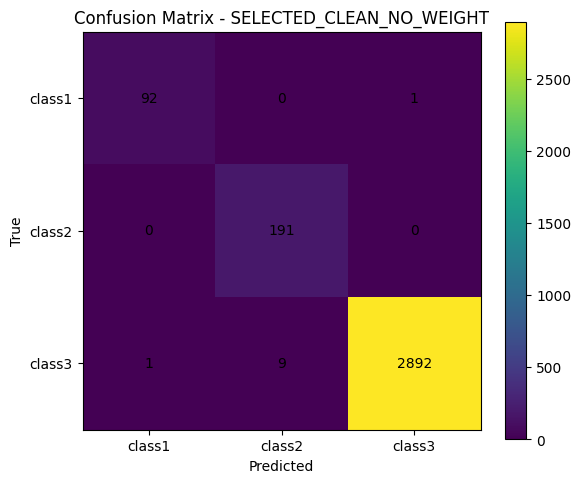

In [15]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_experiment_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

هذه الخلية تدرب أفضل إعداد على كامل بيانات التدريب المختارة ثم تنتج ملف تقديم أولي.  
كما تعرض توزيع توقعات الاختبار وأهمية الميزات، ومنه ثبت أكثر أن ⁦f10⁩ و⁦f14⁩ و⁦f9⁩ من أقوى الميزات.


In [16]:
def fit_final_and_predict(train_data, feature_cols, use_weights, output_name):
    X_train = train_data[feature_cols].copy()
    y_train = train_data[TARGET_COL].copy()
    X_test = test_df[feature_cols].copy()

    model = build_lgbm(random_state=42)

    if use_weights:
        class_weights = make_clipped_alpha_weights(
            y_train,
            alpha=ALPHA,
            max_weight=MAX_WEIGHT,
            min_weight=MIN_WEIGHT
        )

        sample_weights = y_train.map(class_weights).astype(float)

        model.fit(
            X_train,
            y_train,
            sample_weight=sample_weights
        )
    else:
        model.fit(X_train, y_train)

    test_proba = model.predict_proba(X_test)

    proba_df = pd.DataFrame(
        test_proba,
        columns=model.classes_,
        index=test_df.index
    )[sorted(y_train.unique())]

    test_pred = proba_df.idxmax(axis=1)

    submission = pd.DataFrame({
        ID_COL: test_df[ID_COL].values,
        TARGET_COL: test_pred.values
    })

    submission.to_csv(output_name, index=False)

    print("Saved:", output_name)
    print("\nPrediction distribution:")
    print(submission[TARGET_COL].value_counts())

    print("\nPrediction distribution %:")
    print((submission[TARGET_COL].value_counts(normalize=True) * 100).round(2))

    importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nFeature importance:")
    display(importance)

    return model, submission, proba_df


BEST_OUTPUT = f"{best_experiment_name}.csv"

best_model, best_submission, best_test_proba = fit_final_and_predict(
    train_data=best_train_data,
    feature_cols=best_features,
    use_weights=best_use_weights,
    output_name=BEST_OUTPUT
)

Saved: SELECTED_CLEAN_NO_WEIGHT.csv

Prediction distribution:
target
class3    2931
class2     188
class1      81
Name: count, dtype: int64

Prediction distribution %:
target
class3    91.59
class2     5.88
class1     2.53
Name: proportion, dtype: float64

Feature importance:


,feature,importance
3,f10,3635
5,f14,3295
2,f9,2970
1,f2,2686
0,f1,2565
7,f20,2149
4,f12,991
6,f17,755


# 4. تجربة تحسين حدود القرار باستخدام ⁦Logit Bias⁩

بعد أول تجربة كان الموديل جيداً، لكن الأخطاء المتبقية كانت حدودية.  
لذلك لم نغير الموديل مباشرة، بل جربنا تعديل حدود القرار فوق احتمالات الموديل باستخدام ⁦log(probability) + bias⁩.

هذه التجربة مهمة لأنها حسنت النتيجة من غير تعقيد كبير في النموذج.


هذه الخلية تعرف دالة تحويل الاحتمالات إلى ⁦logits⁩ ثم إضافة ⁦bias⁩ لكل فئة.  
الفكرة أن الموديل قد يعطي احتمالات جيدة، لكن القرار النهائي يحتاج ضبطاً بسيطاً بين الفئات.


In [17]:
eps = 1e-12

def predict_with_logit_bias(proba_df, labels, bias_dict):
    scores = np.log(np.clip(proba_df[labels].values, eps, 1.0))

    score_df = pd.DataFrame(
        scores,
        columns=labels,
        index=proba_df.index
    )

    for cls in labels:
        score_df[cls] = score_df[cls] + bias_dict.get(cls, 0.0)

    pred = score_df.idxmax(axis=1)

    return pred


def evaluate_prediction(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "wrong_count": int((y_pred.values != y_true.values).sum())
    }

هذه الخلية تبحث على شبكة قيم للـ ⁦bias_class1⁩ و⁦bias_class2⁩، ثم تقارن المقاييس لكل اختيار.  
الهدف هو تقليل عدد الأخطاء وتحسين ⁦macro F1⁩ بدون تغيير التدريب نفسه.


In [18]:
base_oof_proba = all_probas[best_experiment_name].copy()
base_y_true = best_train_data[TARGET_COL].copy()
base_labels = sorted(base_y_true.unique())

bias_grid_class1 = np.round(np.arange(-1.00, 1.01, 0.05), 2)
bias_grid_class2 = np.round(np.arange(-1.00, 1.01, 0.05), 2)

logit_rows = []

for b1 in bias_grid_class1:
    for b2 in bias_grid_class2:
        bias_dict = {
            "class1": b1,
            "class2": b2,
            "class3": 0.0
        }

        pred = predict_with_logit_bias(
            proba_df=base_oof_proba,
            labels=base_labels,
            bias_dict=bias_dict
        )

        metrics = evaluate_prediction(base_y_true, pred)

        logit_rows.append({
            "bias_class1": b1,
            "bias_class2": b2,
            "bias_class3": 0.0,
            **metrics
        })

logit_df = pd.DataFrame(logit_rows).sort_values(
    by=["f1_macro", "accuracy", "precision_macro"],
    ascending=False
).reset_index(drop=True)

display(logit_df.head(30))

,bias_class1,bias_class2,bias_class3,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,wrong_count
0,0.25,-0.45,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8
1,0.25,-0.40,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8
2,0.25,-0.35,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8
3,0.30,-0.45,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8
4,0.30,-0.40,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8
5,0.30,-0.35,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8
6,0.35,-0.45,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8
7,0.35,-0.40,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8
8,0.35,-0.35,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8
9,0.40,-0.45,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8


هذه الخلية تختار أفضل ⁦bias⁩ من البحث السابق وتعرض النتيجة.  
هنا ظهر أول تحسن واضح: عدد الأخطاء نزل مقارنة بالنسخة الأساسية.


In [19]:
best_logit_row = logit_df.iloc[0]

BEST_BIAS = {
    "class1": float(best_logit_row["bias_class1"]),
    "class2": float(best_logit_row["bias_class2"]),
    "class3": 0.0
}

best_logit_oof_pred = predict_with_logit_bias(
    proba_df=base_oof_proba,
    labels=base_labels,
    bias_dict=BEST_BIAS
)

print("Best logit bias:")
print(BEST_BIAS)

print("\nBest logit OOF metrics:")
display(pd.DataFrame([best_logit_row]))

print("\nClassification report after logits:")
print(classification_report(
    base_y_true,
    best_logit_oof_pred,
    digits=4,
    zero_division=0
))

cm_logit = confusion_matrix(
    base_y_true,
    best_logit_oof_pred,
    labels=base_labels
)

cm_logit_df = pd.DataFrame(
    cm_logit,
    index=[f"true_{c}" for c in base_labels],
    columns=[f"pred_{c}" for c in base_labels]
)

display(cm_logit_df)

Best logit bias:
{'class1': 0.25, 'class2': -0.45, 'class3': 0.0}

Best logit OOF metrics:


,bias_class1,bias_class2,bias_class3,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,wrong_count
0,0.25,-0.45,0.0,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8.0



Classification report after logits:
              precision    recall  f1-score   support

      class1     0.9894    1.0000    0.9947        93
      class2     0.9646    1.0000    0.9820       191
      class3     1.0000    0.9972    0.9986      2902

    accuracy                         0.9975      3186
   macro avg     0.9847    0.9991    0.9918      3186
weighted avg     0.9976    0.9975    0.9975      3186



,pred_class1,pred_class2,pred_class3
true_class1,93,0,0
true_class2,0,191,0
true_class3,1,7,2894


هذه الخلية تقارن قبل وبعد ⁦Logit Bias⁩ مباشرة.  
هذا مهم لأننا لا نريد تجربة تبدو جميلة وحدها؛ نريد رؤية الفرق الحقيقي عن النسخة السابقة.


In [20]:
base_oof_pred = all_preds[best_experiment_name].copy()

before_metrics = evaluate_prediction(base_y_true, base_oof_pred)
after_metrics = evaluate_prediction(base_y_true, best_logit_oof_pred)

compare_logits = pd.DataFrame([
    {
        "method": "Before logits",
        **before_metrics
    },
    {
        "method": "After logits",
        **after_metrics
    }
])

display(compare_logits)

change_df = pd.DataFrame({
    ID_COL: best_train_data[ID_COL].values,
    "true": base_y_true.values,
    "before_logits": base_oof_pred.values,
    "after_logits": best_logit_oof_pred.values
})

change_df["before_correct"] = change_df["before_logits"] == change_df["true"]
change_df["after_correct"] = change_df["after_logits"] == change_df["true"]
change_df["changed"] = change_df["before_logits"] != change_df["after_logits"]

changed_rows = change_df[change_df["changed"]].copy()

print("Changed OOF predictions:", len(changed_rows))

print("\nChange impact:")
print(pd.crosstab(
    change_df["before_correct"],
    change_df["after_correct"],
    rownames=["Before correct"],
    colnames=["After correct"]
))

if len(changed_rows) > 0:
    print("\nChange directions:")
    print(pd.crosstab(
        changed_rows["before_logits"],
        changed_rows["after_logits"],
        rownames=["Before"],
        colnames=["After"]
    ))

display(changed_rows.head(50))

,method,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,wrong_count
0,Before logits,0.996547,0.995267,0.981301,0.995267,0.988110,0.996577,11
1,After logits,0.997489,0.999081,0.984669,0.999081,0.991759,0.997508,8


Changed OOF predictions: 3

Change impact:
After correct   False  True 
Before correct              
False               8      3
True                0   3175

Change directions:
After   class1  class3
Before                
class2       0       2
class3       1       0


,ID,true,before_logits,after_logits,before_correct,after_correct,changed
1112,1115,class3,class2,class3,False,True,True
1195,1198,class1,class3,class1,False,True,True
2869,2883,class3,class2,class3,False,True,True


هذه الخلية تطبق أفضل ⁦bias⁩ على احتمالات الاختبار وتولد ملف تقديم جديد.  
كما تعرض توزيع التوقعات حتى نتأكد أن التعديل لم يغير الفئات بشكل مبالغ فيه.


In [21]:
logit_test_pred = predict_with_logit_bias(
    proba_df=best_test_proba,
    labels=base_labels,
    bias_dict=BEST_BIAS
)

logit_submission = pd.DataFrame({
    ID_COL: test_df[ID_COL].values,
    TARGET_COL: logit_test_pred.values
})

b1_name = str(BEST_BIAS["class1"]).replace(".", "p").replace("-", "m")
b2_name = str(BEST_BIAS["class2"]).replace(".", "p").replace("-", "m")

LOGIT_OUTPUT = f"{best_experiment_name}_LOGITS_b1_{b1_name}_b2_{b2_name}.csv"

logit_submission.to_csv(LOGIT_OUTPUT, index=False)

print("Saved:", LOGIT_OUTPUT)

print("\nPrediction distribution:")
print(logit_submission[TARGET_COL].value_counts())

print("\nPrediction distribution %:")
print((logit_submission[TARGET_COL].value_counts(normalize=True) * 100).round(2))

Saved: SELECTED_CLEAN_NO_WEIGHT_LOGITS_b1_0p25_b2_m0p45.csv

Prediction distribution:
target
class3    2933
class2     186
class1      81
Name: count, dtype: int64

Prediction distribution %:
target
class3    91.66
class2     5.81
class1     2.53
Name: proportion, dtype: float64


هذه الخلية تعرض الصفوف التي بقي الموديل يخطئ فيها بعد ⁦Logit Bias⁩.  
من هنا بدأنا نفهم أن الأخطاء لم تعد كثيرة، لكنها صارت حالات حدودية صعبة.


In [22]:
wrong_df = pd.DataFrame({
    ID_COL: best_train_data[ID_COL].values,
    "true": base_y_true.values,
    "pred": best_logit_oof_pred.values
})

for cls in base_labels:
    wrong_df[f"p_{cls}"] = base_oof_proba[cls].values

wrong_df["wrong"] = wrong_df["true"] != wrong_df["pred"]
wrong_df["margin_pred_vs_class3"] = np.where(
    wrong_df["pred"] == "class1",
    wrong_df["p_class1"] - wrong_df["p_class3"],
    np.where(
        wrong_df["pred"] == "class2",
        wrong_df["p_class2"] - wrong_df["p_class3"],
        np.nan
    )
)

display(
    wrong_df[wrong_df["wrong"]]
    .sort_values("margin_pred_vs_class3")
)

,ID,true,pred,p_class1,p_class2,p_class3,wrong,margin_pred_vs_class3
2093,2104,class3,class2,0.003852,0.756225,0.239923,True,0.516302
2257,2269,class3,class2,0.001408,0.763847,0.234745,True,0.529102
463,464,class3,class2,0.021633,0.858095,0.120272,True,0.737823
1538,1545,class3,class2,0.017340,0.875154,0.107506,True,0.767648
340,341,class3,class2,0.000809,0.931151,0.068040,True,0.863112
2414,2426,class3,class2,0.002047,0.971577,0.026376,True,0.945202
1730,1738,class3,class1,0.961423,0.025950,0.012626,True,0.948797
2446,2458,class3,class2,0.000307,0.989150,0.010543,True,0.978607


## تجربة البحث الأدق حول 
## ⁦bias_class1⁩ و⁦bias_class2⁩

### ما فكرة التجربة؟

بعد تجربة ⁦Logit Bias⁩ الأولى، ظهرت عندنا ملاحظة واضحة من ⁦confusion matrix⁩، وهي أن أغلب الأخطاء المتبقية كانت بين ⁦class2⁩ و⁦class3⁩، وبشكل خاص كان النموذج أحياناً يتوقع ⁦class2⁩ لصفوف حقيقتها ⁦class3⁩.

يعني المشكلة لم تكن أن الموديل ضعيف بشكل عام، بل كانت في حدود القرار بين الفئات القريبة. لذلك بدل أن نعيد تدريب الموديل من البداية، جربنا تعديل حدود القرار بعد خروج الاحتمالات من الموديل.

الفكرة كانت كالتالي:

```text
نأخذ احتمالات الموديل لكل فئة
نحوّلها إلى log scores
نضيف bias لكل class
ثم نختار الفئة التي تملك أعلى score
```

بمعنى آخر، لم نغير ⁦LightGBM⁩ نفسه، بل عدلنا طريقة اتخاذ القرار النهائية.

---

### لماذا ركزنا على ⁦bias_class2⁩؟

من تحليل الأخطاء، لاحظنا أن ⁦class2⁩ حساسة جداً. إذا جعلنا الموديل يتوقع ⁦class2⁩ بسهولة، قد يسحب بعض صفوف ⁦class3⁩ ويتوقعها خطأ على أنها ⁦class2⁩.

لذلك عندما نجعل ⁦bias_class2⁩ سالباً، فنحن عملياً نقول للموديل:

```text
لا تتوقع class2 إلا إذا كان لديك دليل قوي كافٍ.
```

وهذا منطقي لأن ⁦class2⁩ فئة أصغر من ⁦class3⁩، وأي توسع زائد فيها قد يزيد الأخطاء.

أما ⁦bias_class1⁩ فكان الهدف منه ضبط حدود ⁦class1⁩ بشكل بسيط، لأن ⁦class1⁩ أيضاً فئة صغيرة، ولا نريد أن تضيع تماماً بسبب سيطرة ⁦class3⁩.

---

### ماذا كانت نتيجة التجربة؟

قبل هذا التعديل، كانت النتيجة تقريباً:

```text
wrong_count = 8
macro F1 = 0.991759
```

وبعد البحث حول قيم ⁦bias_class1⁩ و⁦bias_class2⁩، وصلنا تقريباً إلى:

```text
bias_class1 = 0.25
bias_class2 = -1.55
bias_class3 = 0
```

وبعد تطبيق هذه القيم، أصبحت النتيجة:

```text
wrong_count = 7
macro F1 = 0.992634
```

يعني التجربة حسّنت النتيجة داخلياً، وخفّضت عدد الأخطاء من ⁦8⁩ إلى ⁦7⁩.

---

### كيف عرفنا أن التحسين حقيقي داخل ⁦OOF⁩؟

لم نعتمد فقط على رقم ⁦macro F1⁩، بل فحصنا الصفوف التي تغيرت توقعاتها بعد تطبيق ⁦bias⁩.

وجدنا أن التعديل غيّر ⁦3⁩ توقعات فقط:

```text
حالتان كانتا true class3 وتوقعهما النموذج class2، وبعد التعديل أصبحتا class3.
هذه الحالات تحسنت.

حالة واحدة كانت true class2، وبعد التعديل أصبحت class3.
هذه الحالة أصبحت أسوأ.
```

يعني التعديل أصلح حالتين وخرب حالة واحدة، لذلك انخفض عدد الأخطاء الكلي من ⁦8⁩ إلى ⁦7⁩.

هذا مهم لأنه يوضح أن التحسن لم يكن عشوائياً، بل ظهر فعلياً من خلال تحليل الأخطاء صفاً صفاً.

---

### ماذا تعلمنا من التجربة؟

تعلمنا أن المشكلة الأساسية ليست في تدريب الموديل فقط، بل أيضاً في حدود القرار بين الفئات. الموديل كان يملك احتمالات جيدة، لكن اختيار الفئة النهائية كان يحتاج إلى ضبط بسيط.

هذه التجربة أثبتت أن تعديل ⁦bias⁩ يمكن أن يحسن أداء النموذج، خصوصاً عند وجود عدم توازن بين الفئات وحدود صعبة بين ⁦class2⁩ و⁦class3⁩.

---

### القرار

هذه التجربة لم تكن النموذج النهائي، لكنها كانت مهمة جداً لأنها أوضحت أن ضبط حدود القرار بين الفئات يحسن النتيجة. لذلك استخدمنا نفس الفكرة لاحقاً داخل تجربة ⁦Repeated CV⁩ و⁦Temperature Logits Ensemble⁩، وهي التجربة التي اعتمدناها في النهاية.


In [ ]:
#========================================================================

# 6. التجربة الأقوى: ⁦Repeated CV⁩ مع ⁦Temperature Logits Ensemble⁩

## ما فكرة التجربة؟

بعد التجارب السابقة وصلنا إلى نتيجة مهمة: نموذج ⁦LightGBM⁩ كان قوي جداً، والميزات المختارة أعطت أداء ممتاز، لكن بقيت بعض الأخطاء الصعبة بين الفئات، خصوصاً بين ⁦class2⁩ و⁦class3⁩.

في التجارب الأولى كنا نعتمد على تقسيم واحد أو تدريب واحد، وهذا قد يجعل النتيجة مرتبطة بجزء معين من البيانات. لذلك قررنا استخدام طريقة أقوى وأكثر ثباتاً:

```text
Repeated CV + Ensemble + Temperature Logits
```

الفكرة ببساطة:

```text
ندرب عدة نماذج LightGBM على تقسيمات مختلفة من البيانات
نحصل على احتمالات OOF لكل صف في التدريب
نحصل على احتمالات test من كل نموذج
نجمع الاحتمالات بمتوسط ensemble
ثم نضبط القرار النهائي باستخدام Temperature Logits و bias
```

يعني بدل أن نعتمد على موديل واحد، اعتمدنا على عدة نماذج، وكل نموذج يرى جزءاً مختلفاً من البيانات، ثم نجمع خبرتهم معاً.

---

## لماذا استخدمنا ⁦Repeated CV⁩؟

استخدمنا ⁦Repeated CV⁩ لأننا لا نريد أن تكون النتيجة معتمدة على تقسيمة واحدة فقط.

لو استخدمنا ⁦StratifiedKFold⁩ مرة واحدة، قد نحصل على نتيجة جيدة، لكن ممكن تكون بسبب أن التقسيمة كانت مناسبة. لذلك كررنا التدريب على أكثر من ⁦seed⁩ وأكثر من ⁦fold⁩.

هذا يعطينا فائدتين:

```text
تقييم داخلي أكثر ثباتاً عن طريق OOF
وتوقعات test أكثر استقراراً عن طريق averaging
```

بمعنى آخر، كل صف في التدريب يتم التنبؤ عليه من نموذج لم يتدرب عليه، وهذا يجعل تقييم ⁦OOF⁩ أقرب للواقع من تقييم الموديل على بيانات رآها أثناء التدريب.

---

## ما معنى ⁦Ensemble⁩ هنا؟

⁦Ensemble⁩ يعني أننا لا نأخذ توقع نموذج واحد فقط، بل نأخذ متوسط احتمالات عدة نماذج.

مثلاً لو عندنا عدة نماذج أعطت احتمالات مختلفة لنفس الصف، نأخذ المتوسط:

```text
model_1 probabilities
model_2 probabilities
model_3 probabilities
...
average probabilities
```

هذا يقلل أثر الأخطاء الفردية. إذا أخطأ نموذج واحد بسبب تقسيمة معينة، النماذج الأخرى قد تعوض هذا الخطأ.

لذلك التوقع النهائي يصبح أكثر ثباتاً وأقل حساسية للتقسيم العشوائي للبيانات.

---

## ما دور ⁦Temperature Logits⁩؟

بعد أن نحصل على متوسط الاحتمالات من ⁦ensemble⁩، لا نأخذ أعلى احتمال مباشرة فقط.
بدل ذلك نستخدم:

```text
score_class = log(probability_class) / T + bias_class
```

ثم نختار الفئة صاحبة أعلى ⁦score⁩.

هنا عندنا جزآن مهمان:

```text
T
bias
```

⁦T⁩ يتحكم في حدة الاحتمالات.
إذا كانت ⁦T⁩ أصغر من ⁦1⁩ تصبح الفروقات بين الفئات أوضح، ويصبح القرار أكثر حدة.

أما ⁦bias⁩ فهو تعديل بسيط على حدود القرار بين الفئات، خصوصاً لأن البيانات غير متوازنة، و⁦class3⁩ هي الفئة الأكبر.

---

## لماذا احتجنا ⁦bias⁩ مع ⁦Temperature⁩؟

من تحليل ⁦confusion matrix⁩ ظهر أن المشكلة ليست فقط في الاحتمالات، بل في حدود القرار بين الفئات.

أحياناً يكون الموديل قريباً جداً بين ⁦class2⁩ و⁦class3⁩، وقرار ⁦argmax⁩ العادي قد يختار الفئة الخطأ.

لذلك استخدمنا ⁦bias⁩ لنضبط القرار النهائي:

```text
bias_class1
bias_class2
bias_class3
```

في النسخة الأفضل كانت الفكرة تقريباً:

```text
نعطي class1 تعديلاً بسيطاً
نجعل class2 أصعب قليلاً
ونترك class3 كفئة مرجعية
```

لذلك استخدمنا قيماً مثل:

```text
T = 0.70
bias_class1 = 0.05
bias_class2 = -2.10
bias_class3 = 0
```

الهدف من ⁦bias_class2⁩ السالب هو تقليل الحالات التي يسحب فيها ⁦class2⁩ صفوفاً من ⁦class3⁩ بالخطأ.

---

## كيف نفذنا التجربة؟

نفذنا التجربة على عدة خطوات:

```text
1. استخدمنا البيانات المنظفة.
2. استخدمنا الميزات المختارة SELECTED8.
3. دربنا LightGBM بعدة folds و seeds.
4. خزّنا احتمالات OOF لكل صف في التدريب.
5. خزّنا احتمالات test من كل نموذج.
6. أخذنا متوسط احتمالات test من جميع النماذج.
7. طبقنا Temperature Logits على احتمالات OOF.
8. بحثنا عن أفضل قيم T و bias.
9. اخترنا القيم التي أعطت أقل wrong_count وأفضل macro F1.
10. طبقنا نفس القيم على احتمالات test لإنتاج ملف submission.
```

هذا جعل التجربة أقوى من التجارب السابقة لأنها تجمع بين:

```text
ثبات Repeated CV
قوة LightGBM
تقليل التذبذب عبر Ensemble
تحسين حدود القرار عبر Temperature Logits
```

---

## ماذا كانت نتيجة التجربة؟

قبل هذه المرحلة، كانت أفضل التجارب السابقة تقريباً تصل إلى:

```text
wrong_count = 7
macro F1 ≈ 0.992634
```

بعد استخدام ⁦Repeated CV⁩ مع ⁦Temperature Logits Ensemble⁩ وصلت النتيجة الداخلية إلى تقريباً:

```text
wrong_count = 4
macro F1 ≈ 0.99538
```

يعني هذه التجربة خفّضت عدد أخطاء ⁦OOF⁩ من ⁦7⁩ إلى ⁦4⁩، وهذا تحسن واضح.

كما أعطت أفضل نتيجة لنا على ⁦Public Leaderboard⁩:

```text
Public Score = 0.98435
```

وهذا كان أفضل ملف اعتمدناه.

---

## ماذا ظهر من ⁦confusion matrix⁩؟

بعد هذه التجربة، أصبحت الأخطاء قليلة جداً.
لكن الأخطاء المتبقية بقيت غالباً ضمن الحالات الحدودية الصعبة بين الفئات.

هذا مهم، لأن ⁦confusion matrix⁩ أوضحت لنا أن الموديل لم يعد يخطئ بشكل عام، بل بقيت فقط حالات قليلة جداً تقع على الحدود بين ⁦class2⁩ و⁦class3⁩، أو حالات شاذة يصعب فصلها حتى على أقرب الجيران.

بمعنى آخر، التجربة لم تحسن الرقم فقط، بل جعلت الموديل أكثر استقراراً، وقللت الأخطاء إلى عدد صغير جداً.


---

النموذج النهائي أصبح:

```text
LightGBM
SELECTED8 features
cleaned training data
Repeated StratifiedKFold
Ensemble probabilities
Temperature Logits
Logit Bias
```


هذه هي أهم تجربة في النوت بوك.  
بعد أن عرفنا أن ⁦LightGBM⁩ هو الأقوى، وأن ⁦logit bias⁩ يحسن حدود القرار، انتقلنا إلى نسخة أكثر ثباتاً:

- تدريب متكرر باستخدام عدة ⁦seeds⁩.
- تجميع احتمالات ⁦OOF⁩ بالمتوسط.
- البحث عن أفضل ⁦temperature⁩ و⁦bias⁩.
- تحليل ⁦confusion matrix⁩ والأخطاء المتبقية.

هذه التجربة هي التي قادتنا إلى المسار النهائي القوي.


هذه الخلية تعيد استيراد المكتبات المطلوبة للتجربة النهائية المتكررة.  
فصلناها هنا حتى تكون تجربة ⁦Repeated CV⁩ قابلة للتشغيل لوحدها بوضوح.


In [14]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

هذه الخلية تعيد قراءة بيانات التدريب والاختبار وتعرض توزيع الفئات.  
نكرر هذا العرض هنا لأن هذه التجربة هي أهم تجربة ونريد أن تكون مكتملة بذاتها.


In [15]:
DATA_DIR = Path(".")

TRAIN_PATH = DATA_DIR / "train_data.csv"
TEST_PATH = DATA_DIR / "test_data.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

ID_COL = "ID"
TARGET_COL = "target"

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTarget distribution:")
print(train_df[TARGET_COL].value_counts())

print("\nTarget distribution %:")
print((train_df[TARGET_COL].value_counts(normalize=True) * 100).round(2))

Train shape: (3200, 23)
Test shape: (3200, 22)

Target distribution:
target
class3    2916
class2     191
class1      93
Name: count, dtype: int64

Target distribution %:
target
class3    91.12
class2     5.97
class1     2.91
Name: proportion, dtype: float64


هذه الخلية تعيد تحديد ⁦SELECTED8⁩ وتطبق نفس تنظيف الصفوف المشبوهة.  
المهم أن التجربة النهائية تستخدم نفس منطق التنظيف الذي ثبت أنه أفضل في البداية.


In [16]:
DROP_COLS = [
    "f19", "f7", "f16", "f21",
    "f3", "f5", "f6", "f8", "f11", "f15",
    "f13", "f4", "f18"
]

ALL_FEATURES = [
    c for c in train_df.columns
    if c not in [ID_COL, TARGET_COL]
]

SELECTED_FEATURES = [
    c for c in ALL_FEATURES
    if c not in DROP_COLS
]

print("Selected features:", SELECTED_FEATURES)

assert SELECTED_FEATURES == ["f1", "f2", "f9", "f10", "f12", "f14", "f17", "f20"]


def detect_noisy_class3_rows(df):
    class3_mask = df[TARGET_COL] == "class3"

    high_f10_mask = df["f10"] > 0.02

    class3_f9_q95 = df.loc[class3_mask, "f9"].quantile(0.95)
    class3_f14_q95 = df.loc[class3_mask, "f14"].quantile(0.95)

    normal_f9_f14_mask = (
        (df["f9"] <= class3_f9_q95) &
        (df["f14"] <= class3_f14_q95)
    )

    noisy_mask = class3_mask & high_f10_mask & normal_f9_f14_mask

    return noisy_mask


noisy_mask = detect_noisy_class3_rows(train_df)

train_clean = train_df.loc[~noisy_mask].copy().reset_index(drop=True)

print("\nOriginal train shape:", train_df.shape)
print("Clean train shape:", train_clean.shape)
print("Removed rows:", len(train_df) - len(train_clean))

print("\nRemoved target distribution:")
print(train_df.loc[noisy_mask, TARGET_COL].value_counts())

print("\nClean target distribution:")
print(train_clean[TARGET_COL].value_counts())

Selected features: ['f1', 'f2', 'f9', 'f10', 'f12', 'f14', 'f17', 'f20']

Original train shape: (3200, 23)
Clean train shape: (3186, 23)
Removed rows: 14

Removed target distribution:
target
class3    14
Name: count, dtype: int64

Clean target distribution:
target
class3    2902
class2     191
class1      93
Name: count, dtype: int64


هذه الخلية تجهز ⁦X⁩ و⁦y⁩ و⁦X_test⁩ وتثبت ترتيب الفئات.  
ترتيب الفئات مهم جداً لأننا سنطبق ⁦temperature logits⁩ على مصفوفة احتمالات.


In [17]:
X = train_clean[SELECTED_FEATURES].copy()
y = train_clean[TARGET_COL].copy()
X_test = test_df[SELECTED_FEATURES].copy()

labels = sorted(y.unique())

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("Labels:", labels)

assert list(X.columns) == list(X_test.columns)

X shape: (3186, 8)
X_test shape: (3200, 8)
Labels: ['class1', 'class2', 'class3']


هذه الخلية تعرف نسختين من ⁦LightGBM⁩ للمقارنة داخل التجربة النهائية.  
الهدف أن لا نعتمد إعداداً واحداً فقط قبل التحقق من الأفضل.


In [18]:
MODEL_VARIANTS = {
    "LGBM_CONSERVATIVE_900": {
        "n_estimators": 900,
        "learning_rate": 0.015,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 15,
        "subsample": 0.90,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.05,
        "reg_lambda": 3.0,
    },

    "LGBM_TUNED_850": {
        "n_estimators": 850,
        "learning_rate": 0.0427,
        "num_leaves": 22,
        "max_depth": 5,
        "min_child_samples": 12,
        "subsample": 0.90,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.05,
        "reg_lambda": 3.0,
    },
}


def build_lgbm(params, random_state=42):
    return LGBMClassifier(
        objective="multiclass",
        **params,
        random_state=random_state,
        n_jobs=-1,
        verbosity=-1
    )

هذه الخلية تعرف دالة بناء احتمالات ⁦OOF⁩ المتكررة عبر عدة ⁦seeds⁩.  
الميزة هنا أن كل صف يحصل على احتمالات أكثر ثباتاً من نموذج واحد أو تقسيمة واحدة.


In [19]:
REPEATED_CV_SEEDS = [42, 101, 202, 303, 404]


def build_repeated_oof_proba(params, X_data, y_data, labels, seeds):
    oof_sum = pd.DataFrame(
        0.0,
        index=X_data.index,
        columns=labels
    )

    oof_count = pd.Series(
        0,
        index=X_data.index,
        dtype=int
    )

    fold_rows = []

    for seed in seeds:
        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed
        )

        for fold, (tr_idx, val_idx) in enumerate(cv.split(X_data, y_data), 1):
            X_train = X_data.iloc[tr_idx]
            X_val = X_data.iloc[val_idx]
            y_train = y_data.iloc[tr_idx]
            y_val = y_data.iloc[val_idx]

            model = build_lgbm(params, random_state=seed + fold)
            model.fit(X_train, y_train)

            proba_raw = model.predict_proba(X_val)

            proba_df = pd.DataFrame(
                proba_raw,
                columns=model.classes_,
                index=X_val.index
            )[labels]

            oof_sum.loc[X_val.index, labels] += proba_df
            oof_count.loc[X_val.index] += 1

            pred = proba_df.idxmax(axis=1)

            fold_rows.append({
                "seed": seed,
                "fold": fold,
                "accuracy": accuracy_score(y_val, pred),
                "f1_macro": f1_score(y_val, pred, average="macro", zero_division=0),
                "wrong_count": int((pred.values != y_val.values).sum())
            })

    oof_proba = oof_sum.div(oof_count, axis=0)

    assert oof_count.min() == len(seeds)
    assert oof_proba.isna().sum().sum() == 0

    return oof_proba, pd.DataFrame(fold_rows)


def predict_temp_logits_arr(proba_arr, temperature, b1, b2):
    eps = 1e-12

    scores = np.log(np.clip(proba_arr, eps, 1.0)) / temperature
    scores = scores + np.array([b1, b2, 0.0])

    return scores.argmax(axis=1)


def fast_metrics_from_int(y_int, pred_int):
    cm = np.bincount(
        y_int * 3 + pred_int,
        minlength=9
    ).reshape(3, 3)

    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp

    precision = np.divide(
        tp,
        tp + fp,
        out=np.zeros_like(tp),
        where=(tp + fp) != 0
    )

    recall = np.divide(
        tp,
        tp + fn,
        out=np.zeros_like(tp),
        where=(tp + fn) != 0
    )

    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp),
        where=(precision + recall) != 0
    )

    return {
        "accuracy": float((pred_int == y_int).mean()),
        "precision_macro": float(precision.mean()),
        "recall_macro": float(recall.mean()),
        "f1_macro": float(f1.mean()),
        "wrong_count": int((pred_int != y_int).sum()),
        "class1_precision": float(precision[0]),
        "class1_recall": float(recall[0]),
        "class2_precision": float(precision[1]),
        "class2_recall": float(recall[1]),
        "class3_precision": float(precision[2]),
        "class3_recall": float(recall[2]),
        "c3_to_c1": int(cm[2, 0]),
        "c3_to_c2": int(cm[2, 1]),
        "c2_to_c3": int(cm[1, 2]),
    }

هذه الخلية تبحث عبر إعدادات ⁦temperature⁩ و⁦bias_class1⁩ و⁦bias_class2⁩ لكل نسخة من ⁦LightGBM⁩.  
هذا هو الجزء الذي يربط بين قوة الموديل وثبات حدود القرار.


In [20]:
label_to_int = {label: i for i, label in enumerate(labels)}
int_to_label = {i: label for label, i in label_to_int.items()}

y_int = np.array([label_to_int[v] for v in y.values])

T_grid = np.round(np.arange(0.65, 0.91, 0.025), 3)
b1_grid = np.round(np.arange(0.05, 0.201, 0.01), 3)
b2_grid = np.round(np.arange(-2.10, -1.20, 0.01), 3)

all_search_rows = []
oof_store = {}
fold_store = {}

for variant_name, params in MODEL_VARIANTS.items():
    print("=" * 100)
    print("Building repeated OOF for:", variant_name)

    oof_proba, fold_df = build_repeated_oof_proba(
        params=params,
        X_data=X,
        y_data=y,
        labels=labels,
        seeds=REPEATED_CV_SEEDS
    )

    oof_store[variant_name] = oof_proba
    fold_store[variant_name] = fold_df

    proba_arr = oof_proba[labels].values

    for T in T_grid:
        for b1 in b1_grid:
            for b2 in b2_grid:
                pred_int = predict_temp_logits_arr(
                    proba_arr=proba_arr,
                    temperature=float(T),
                    b1=float(b1),
                    b2=float(b2)
                )

                metrics = fast_metrics_from_int(y_int, pred_int)

                all_search_rows.append({
                    "variant": variant_name,
                    "temperature": float(T),
                    "bias_class1": float(b1),
                    "bias_class2": float(b2),
                    "bias_class3": 0.0,
                    **metrics
                })

search_df = pd.DataFrame(all_search_rows).sort_values(
    by=[
        "f1_macro",
        "accuracy",
        "precision_macro",
        "wrong_count",
        "c3_to_c2",
        "c2_to_c3"
    ],
    ascending=[False, False, False, True, True, True]
).reset_index(drop=True)

display(search_df.head(50))

Building repeated OOF for: LGBM_CONSERVATIVE_900
Building repeated OOF for: LGBM_TUNED_850


,variant,temperature,bias_class1,bias_class2,bias_class3,accuracy,precision_macro,recall_macro,f1_macro,wrong_count,class1_precision,class1_recall,class2_precision,class2_recall,class3_precision,class3_recall,c3_to_c1,c3_to_c2,c2_to_c3
0,LGBM_TUNED_850,0.7,0.05,-2.10,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
1,LGBM_TUNED_850,0.7,0.05,-2.09,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
2,LGBM_TUNED_850,0.7,0.05,-2.08,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
3,LGBM_TUNED_850,0.7,0.05,-2.07,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
4,LGBM_TUNED_850,0.7,0.05,-2.06,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
5,LGBM_TUNED_850,0.7,0.06,-2.10,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
6,LGBM_TUNED_850,0.7,0.06,-2.09,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
7,LGBM_TUNED_850,0.7,0.06,-2.08,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
8,LGBM_TUNED_850,0.7,0.06,-2.07,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
9,LGBM_TUNED_850,0.7,0.06,-2.06,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1


هذه الخلية تختار أفضل إعداد من البحث النهائي وتعرض ⁦classification report⁩ و⁦confusion matrix⁩.  
هذه النتيجة هي أقوى نتيجة داخلية وصلنا لها، ولذلك كانت أساس الكود النهائي.


In [21]:
best_row = search_df.iloc[0]

BEST_VARIANT = best_row["variant"]
BEST_PARAMS = MODEL_VARIANTS[BEST_VARIANT]

BEST_T = float(best_row["temperature"])
BEST_B1 = float(best_row["bias_class1"])
BEST_B2 = float(best_row["bias_class2"])

BEST_BIAS = {
    "class1": BEST_B1,
    "class2": BEST_B2,
    "class3": 0.0
}

best_oof_proba = oof_store[BEST_VARIANT]
best_proba_arr = best_oof_proba[labels].values

best_pred_int = predict_temp_logits_arr(
    proba_arr=best_proba_arr,
    temperature=BEST_T,
    b1=BEST_B1,
    b2=BEST_B2
)

best_pred_labels = pd.Series(
    [int_to_label[i] for i in best_pred_int],
    index=y.index
)

print("Best variant:", BEST_VARIANT)
print("BEST_T:", BEST_T)
print("BEST_BIAS:", BEST_BIAS)

print("\nOOF Classification Report:")
print(classification_report(
    y,
    best_pred_labels,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(
    y,
    best_pred_labels,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in labels],
    columns=[f"pred_{c}" for c in labels]
)

display(cm_df)

best_metrics = fast_metrics_from_int(y_int, best_pred_int)
display(pd.DataFrame([best_metrics]))

if best_metrics["wrong_count"] == 5:
    print("OK: وصلت إلى نسخة الخمس أخطاء.")
else:
    print("WARNING: لم تصل إلى خمس أخطاء. هذا يعني أن خلية repeated_oof_proba القديمة كانت تستخدم إعدادات أو seed مختلفة.")

Best variant: LGBM_TUNED_850
BEST_T: 0.7
BEST_BIAS: {'class1': 0.05, 'class2': -2.1, 'class3': 0.0}

OOF Classification Report:
              precision    recall  f1-score   support

      class1     0.9894    1.0000    0.9947        93
      class2     0.9896    0.9948    0.9922       191
      class3     0.9997    0.9990    0.9993      2902

    accuracy                         0.9987      3186
   macro avg     0.9929    0.9979    0.9954      3186
weighted avg     0.9988    0.9987    0.9987      3186



,pred_class1,pred_class2,pred_class3
true_class1,93,0,0
true_class2,0,190,1
true_class3,1,2,2899


,accuracy,precision_macro,recall_macro,f1_macro,wrong_count,class1_precision,class1_recall,class2_precision,class2_recall,class3_precision,class3_recall,c3_to_c1,c3_to_c2,c2_to_c3
0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1


هذه الخلية تعرض الأسطر التي أخطأ فيها الموديل النهائي داخلياً مع احتمالات كل كلاس.  
هذا يوضح أن الأخطاء المتبقية قليلة جداً ومعظمها حالات صعبة وحدودية.


In [22]:
error_df = train_clean[[ID_COL] + SELECTED_FEATURES + [TARGET_COL]].copy()
error_df["pred"] = best_pred_labels.values

for i, cls in enumerate(labels):
    error_df[f"p_{cls}"] = best_oof_proba[cls].values

error_df["wrong"] = error_df[TARGET_COL] != error_df["pred"]

wrong_df = error_df[error_df["wrong"]].copy()

print("Wrong count:", len(wrong_df))

display(
    wrong_df[
        [ID_COL, TARGET_COL, "pred",
         "p_class1", "p_class2", "p_class3",
         "f1", "f2", "f9", "f10", "f12", "f14", "f17", "f20"]
    ].sort_values([TARGET_COL, "pred"])
)

Wrong count: 4


,ID,target,pred,p_class1,p_class2,p_class3,f1,f2,f9,f10,f12,f14,f17,f20
676,678,class2,class3,0.002667,0.596983,0.400350,0.34,0.0390,0.146,0.01900,0,0.125,0,0.116
1730,1738,class3,class1,0.960423,0.035290,0.004287,0.85,0.0240,0.066,0.00730,0,0.061,0,0.109
2414,2426,class3,class2,0.000557,0.990733,0.008710,0.60,0.0206,0.045,0.00650,0,0.096,0,0.047
2446,2458,class3,class2,0.000099,0.994378,0.005523,0.79,0.0340,0.094,0.01209,0,0.102,0,0.092


# 7. تجربة ⁦KNN Hybrid⁩ 

## ما فكرة التجربة؟

بعد أن وصلنا إلى نتيجة قوية جداً باستخدام ⁦LightGBM⁩ مع ⁦Repeated CV⁩ و⁦Temperature Logits⁩، بقي عندنا عدد قليل جداً من الأخطاء. هذه الأخطاء لم تكن عشوائية، بل كانت غالباً في الصفوف القريبة من حدود القرار بين الفئات، خصوصاً بين ⁦class2⁩ و⁦class3⁩.

لذلك جربنا فكرة مختلفة: بدل أن نستبدل ⁦LightGBM⁩ بالكامل، نستخدم ⁦KNN⁩ كطريقة مساعدة فقط للحالات الحدودية.

يعني الفكرة لم تكن:

```text
استبدال LightGBM بـ KNN
```

بل كانت:

```text
نحافظ على توقعات LightGBM
ثم نستخدم KNN فقط كـ fallback للحالات التي يكون فيها الموديل غير واثق تماماً
```

بمعنى آخر، ⁦KNN⁩ هنا كان مساعداً، وليس النموذج الأساسي.

---

## لماذا فكرنا باستخدام ⁦KNN⁩؟

⁦KNN⁩ يعتمد على فكرة بسيطة جداً:

```text
إذا كان صف معين قريباً من صفوف تدريب تنتمي لفئة معينة،
فغالباً هذا الصف ينتمي لنفس الفئة.
```

وهذا مفيد في حالتنا لأن بعض الأخطاء كانت حدودية. يعني الصف قد يكون قريباً جداً من ⁦class2⁩ و⁦class3⁩ معاً، وقرار ⁦LightGBM⁩ قد يتأثر بفارق صغير في الاحتمالات.

لذلك قلنا: في الحالات التي يكون فيها الفرق بين أعلى احتمالين صغيراً، يمكن أن نسمح لـ ⁦KNN⁩ أن يشارك في القرار.

---

## كيف نفذنا التجربة؟

بدأنا من أفضل احتمالات حصلنا عليها من تجربة ⁦LightGBM⁩ النهائية، ثم بنينا احتمالات ⁦KNN⁩ بطريقة ⁦OOF⁩ أيضاً، حتى يكون التقييم عادلاً.

استخدمنا عدة إعدادات لـ ⁦KNN⁩:

```text
feature sets مختلفة
قيم مختلفة لـ k
دمج احتمالات KNN مع احتمالات LightGBM بنسب مختلفة
تطبيق الدمج فقط على الحالات الحدودية
```

أهم فكرة في الدمج كانت:

```text
إذا كان الفرق بين أعلى احتمالين صغيراً،
نعتبر الصف حالة حدودية،
وندمج جزءاً صغيراً من احتمالات KNN مع احتمالات LightGBM.
```

أما إذا كان ⁦LightGBM⁩ واثقاً جداً، لا نغيّر قراره.

---

## لماذا استخدمنا ⁦StandardScaler⁩؟

استخدمنا ⁦StandardScaler⁩ لأن ⁦KNN⁩ يعتمد على المسافات بين الصفوف.
إذا كانت ميزة رقمية أكبر من غيرها في المقياس، قد تسيطر على حساب المسافة وتخرب النتيجة.

لذلك قبل تدريب ⁦KNN⁩، قمنا بتوحيد مقياس الميزات حتى تصبح المقارنة بين الصفوف أكثر عدلاً.

---

## ما الميزات التي كانت أفضل مع ⁦KNN⁩؟

أفضل نتيجة ظهرت عندما استخدمنا الميزات الحدودية التالية:

```text
f1
f9
f10
f14
```

وهذا منطقي، لأن هذه الميزات كانت من أكثر الميزات المرتبطة بالفصل بين الفئات، خصوصاً بين ⁦class2⁩ و⁦class3⁩.

أفضل إعداد كان تقريباً:

```text
features = f1, f9, f10, f14
k = 3
margin_threshold = 0.02
knn_weight = 0.25
T = 0.50
bias_class1 = -0.05
bias_class2 = -3.00
bias_class3 = 0
```

معنى هذا أن ⁦KNN⁩ لم يكن صاحب القرار الكامل، بل شارك بنسبة صغيرة فقط في الحالات الحدودية.

---

## ماذا كانت نتيجة التجربة؟

أفضل نتيجة داخلية لهذه التجربة كانت قريبة جداً من أفضل نتيجة نهائية:

```text
accuracy = 0.998745
macro F1 = 0.995377
wrong_count = 4
```

وهذه نتيجة قوية، لأنها وصلت إلى نفس عدد الأخطاء تقريباً في التجربة النهائية الأساسية.

---

## ماذا ظهر من ⁦confusion matrix⁩؟

مصفوفة الارتباك كانت تقريباً:

```text
              pred_class1  pred_class2  pred_class3
true_class1           93            0            0
true_class2            0          190            1
true_class3            1            2         2899
```

يعني:

```text
class1: كل الصفوف تم تصنيفها بشكل صحيح.
class2: يوجد خطأ واحد فقط ذهب إلى class3.
class3: يوجد 3 أخطاء، واحد ذهب إلى class1 واثنان ذهبا إلى class2.
```

إجمالي الأخطاء بقي:

```text
wrong_count = 4
```

وهذا يوضح أن ⁦KNN Hybrid⁩ كان قوياً داخلياً، لكنه لم يعطِ تفوقاً واضحاً فوق التجربة النهائية.



أبقينا هذه التجربة لأنها مفيدة في الشرح.  
استخدمنا ⁦KNN⁩ كطريقة مساعدة للحالات الحدودية بين الفئات، وليس كبديل مباشر عن ⁦LightGBM⁩.

النتيجة كانت قريبة جداً من أفضل نتيجة داخلية، لكنها لم تكن أبسط أو أوضح من المسار النهائي، لذلك لم نعتمدها كنموذج نهائي.  
يعني استفدنا منها كتحليل إضافي، لكن القرار النهائي بقي مع ⁦LightGBM⁩ و⁦Temperature Logits⁩.


هذه الخلية تعرف دالة بناء احتمالات ⁦OOF⁩ باستخدام ⁦KNN⁩.  
نستخدم ⁦StandardScaler⁩ لأن ⁦KNN⁩ حساس جداً لمقياس الميزات.


In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold

def build_repeated_knn_oof_proba(
    X_data,
    y_data,
    labels,
    feature_cols,
    seeds,
    k=5,
    weights="distance"
):
    oof_sum = pd.DataFrame(
        0.0,
        index=X_data.index,
        columns=labels
    )

    oof_count = pd.Series(
        0,
        index=X_data.index,
        dtype=int
    )

    fold_rows = []

    X_use = X_data[feature_cols].copy()

    for seed in seeds:
        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed
        )

        for fold, (tr_idx, val_idx) in enumerate(cv.split(X_use, y_data), 1):
            X_tr = X_use.iloc[tr_idx]
            X_val = X_use.iloc[val_idx]
            y_tr = y_data.iloc[tr_idx]
            y_val = y_data.iloc[val_idx]

            scaler = StandardScaler()
            X_tr_scaled = scaler.fit_transform(X_tr)
            X_val_scaled = scaler.transform(X_val)

            knn = KNeighborsClassifier(
                n_neighbors=k,
                weights=weights,
                metric="euclidean"
            )

            knn.fit(X_tr_scaled, y_tr)

            proba_raw = knn.predict_proba(X_val_scaled)

            proba_df = pd.DataFrame(
                0.0,
                index=X_val.index,
                columns=labels
            )

            for i, cls in enumerate(knn.classes_):
                proba_df[cls] = proba_raw[:, i]

            oof_sum.loc[X_val.index, labels] += proba_df[labels]
            oof_count.loc[X_val.index] += 1

            pred = proba_df[labels].idxmax(axis=1)

            fold_rows.append({
                "seed": seed,
                "fold": fold,
                "accuracy": accuracy_score(y_val, pred),
                "f1_macro": f1_score(y_val, pred, average="macro", zero_division=0),
                "wrong_count": int((pred.values != y_val.values).sum())
            })

    oof_proba = oof_sum.div(oof_count, axis=0)

    assert oof_count.min() == len(seeds)
    assert oof_proba.isna().sum().sum() == 0

    return oof_proba, pd.DataFrame(fold_rows)

هذه الخلية تجرب دمج ⁦KNN⁩ فقط على الحالات الحدودية، بدل أن تغير كل التوقعات.  
الفكرة كانت أن ⁦KNN⁩ قد يساعد في الصفوف القريبة من حد ⁦class2/class3⁩.


In [67]:
def quick_search_logits_for_hybrid(proba_df, labels, y_int):
    proba_arr = proba_df[labels].values

    T_grid = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
    b1_grid = [-0.05, 0.0, 0.05]
    b2_grid = [-3.0, -2.8, -2.6, -2.4, -2.2, -2.1, -2.0]

    rows = []

    for T in T_grid:
        for b1 in b1_grid:
            for b2 in b2_grid:
                pred_int = predict_temp_logits_arr(
                    proba_arr=proba_arr,
                    temperature=float(T),
                    b1=float(b1),
                    b2=float(b2)
                )

                metrics = fast_metrics_from_int(y_int, pred_int)

                rows.append({
                    "temperature": float(T),
                    "bias_class1": float(b1),
                    "bias_class2": float(b2),
                    "bias_class3": 0.0,
                    **metrics
                })

    return pd.DataFrame(rows).sort_values(
        by=["f1_macro", "accuracy", "precision_macro", "wrong_count", "c3_to_c2", "c2_to_c3"],
        ascending=[False, False, False, True, True, True]
    ).reset_index(drop=True)


BASE_HYBRID_OOF = best_oof_proba.copy()

base_hybrid_pred_int = predict_temp_logits_arr(
    proba_arr=BASE_HYBRID_OOF[labels].values,
    temperature=BEST_T,
    b1=BEST_B1,
    b2=BEST_B2
)

base_hybrid_pred_labels = pd.Series(
    [int_to_label[i] for i in base_hybrid_pred_int],
    index=y.index
)

KNN_FEATURE_SETS = {
    "boundary4": ["f1", "f9", "f10", "f14"],
    "boundary6": ["f1", "f2", "f9", "f10", "f14", "f20"],
    "selected8": SELECTED_FEATURES
}

k_grid = [3, 5, 7, 11]
margin_grid = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20]
knn_weight_grid = [0.25, 0.50, 0.75, 1.00]

hybrid_rows = []
hybrid_store = {}

for feat_name, feat_cols in KNN_FEATURE_SETS.items():
    for k in k_grid:
        print("=" * 100)
        print("Building KNN OOF:", feat_name, "k =", k)

        knn_oof, knn_fold_df = build_repeated_knn_oof_proba(
            X_data=train_clean,
            y_data=y,
            labels=labels,
            feature_cols=feat_cols,
            seeds=REPEATED_CV_SEEDS,
            k=k,
            weights="distance"
        )

        for margin_thr in margin_grid:
            boundary_mask = (
                base_hybrid_pred_labels.isin(["class2", "class3"]) &
                (np.abs(BASE_HYBRID_OOF["class2"] - BASE_HYBRID_OOF["class3"]) <= margin_thr)
            )

            for knn_w in knn_weight_grid:
                hybrid_oof = BASE_HYBRID_OOF.copy()

                hybrid_oof.loc[boundary_mask, labels] = (
                    (1.0 - knn_w) * BASE_HYBRID_OOF.loc[boundary_mask, labels] +
                    knn_w * knn_oof.loc[boundary_mask, labels]
                )

                search_df = quick_search_logits_for_hybrid(
                    proba_df=hybrid_oof,
                    labels=labels,
                    y_int=y_int
                )

                best_row = search_df.iloc[0].to_dict()

                exp_name = f"{feat_name}_k{k}_margin{margin_thr}_w{knn_w}"

                best_row.update({
                    "experiment": exp_name,
                    "feature_set": feat_name,
                    "k": k,
                    "margin_thr": margin_thr,
                    "knn_weight": knn_w,
                    "changed_boundary_oof": int(boundary_mask.sum())
                })

                hybrid_rows.append(best_row)

                hybrid_store[exp_name] = {
                    "features": feat_cols,
                    "k": k,
                    "knn_weight": knn_w,
                    "margin_thr": margin_thr,
                    "knn_oof": knn_oof,
                    "hybrid_oof": hybrid_oof,
                    "search_df": search_df,
                    "best_row": best_row
                }

hybrid_df = pd.DataFrame(hybrid_rows).sort_values(
    by=["f1_macro", "accuracy", "precision_macro", "wrong_count", "c3_to_c2", "c2_to_c3"],
    ascending=[False, False, False, True, True, True]
).reset_index(drop=True)

display(hybrid_df.head(50))

Building KNN OOF: boundary4 k = 3
Building KNN OOF: boundary4 k = 5
Building KNN OOF: boundary4 k = 7
Building KNN OOF: boundary4 k = 11
Building KNN OOF: boundary6 k = 3
Building KNN OOF: boundary6 k = 5
Building KNN OOF: boundary6 k = 7
Building KNN OOF: boundary6 k = 11
Building KNN OOF: selected8 k = 3
Building KNN OOF: selected8 k = 5
Building KNN OOF: selected8 k = 7
Building KNN OOF: selected8 k = 11


,temperature,bias_class1,bias_class2,bias_class3,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,wrong_count,...,class3_recall,c3_to_c1,c3_to_c2,c2_to_c3,experiment,feature_set,k,margin_thr,knn_weight,changed_boundary_oof
0,0.5,-0.05,-3.0,0.0,0.998745,0.99791,0.992867,0.99791,0.995377,4.0,...,0.998966,1.0,2.0,1.0,boundary4_k3_margin0.02_w0.25,boundary4,3,0.02,0.25,0
1,0.5,-0.05,-3.0,0.0,0.998745,0.99791,0.992867,0.99791,0.995377,4.0,...,0.998966,1.0,2.0,1.0,boundary4_k3_margin0.02_w0.5,boundary4,3,0.02,0.50,0
2,0.5,-0.05,-3.0,0.0,0.998745,0.99791,0.992867,0.99791,0.995377,4.0,...,0.998966,1.0,2.0,1.0,boundary4_k3_margin0.02_w0.75,boundary4,3,0.02,0.75,0
3,0.5,-0.05,-3.0,0.0,0.998745,0.99791,0.992867,0.99791,0.995377,4.0,...,0.998966,1.0,2.0,1.0,boundary4_k3_margin0.02_w1.0,boundary4,3,0.02,1.00,0
4,0.5,-0.05,-3.0,0.0,0.998745,0.99791,0.992867,0.99791,0.995377,4.0,...,0.998966,1.0,2.0,1.0,boundary4_k3_margin0.05_w0.25,boundary4,3,0.05,0.25,2
5,0.5,-0.05,-3.0,0.0,0.998745,0.99791,0.992867,0.99791,0.995377,4.0,...,0.998966,1.0,2.0,1.0,boundary4_k3_margin0.05_w0.5,boundary4,3,0.05,0.50,2
6,0.5,-0.05,-3.0,0.0,0.998745,0.99791,0.992867,0.99791,0.995377,4.0,...,0.998966,1.0,2.0,1.0,boundary4_k3_margin0.05_w0.75,boundary4,3,0.05,0.75,2
7,0.5,-0.05,-3.0,0.0,0.998745,0.99791,0.992867,0.99791,0.995377,4.0,...,0.998966,1.0,2.0,1.0,boundary4_k3_margin0.05_w1.0,boundary4,3,0.05,1.00,2
8,0.5,-0.05,-3.0,0.0,0.998745,0.99791,0.992867,0.99791,0.995377,4.0,...,0.998966,1.0,2.0,1.0,boundary4_k3_margin0.08_w0.25,boundary4,3,0.08,0.25,2
9,0.5,-0.05,-3.0,0.0,0.998745,0.99791,0.992867,0.99791,0.995377,4.0,...,0.998966,1.0,2.0,1.0,boundary4_k3_margin0.08_w0.5,boundary4,3,0.08,0.50,2


هذه الخلية تختار أفضل إعداد ⁦KNN Hybrid⁩ وتعرض التقرير ومصفوفة الارتباك.  
رغم أن النتيجة قريبة جداً، لم نعتمده لأنه أكثر تعقيداً ولم يعطِ تفوقاً أوضح من النسخة النهائية.


In [68]:
best_hybrid_row = hybrid_df.iloc[0]

BEST_HYBRID_EXP = best_hybrid_row["experiment"]
BEST_HYBRID_INFO = hybrid_store[BEST_HYBRID_EXP]

BEST_HYBRID_OOF = BEST_HYBRID_INFO["hybrid_oof"]

BEST_HYBRID_T = float(best_hybrid_row["temperature"])
BEST_HYBRID_B1 = float(best_hybrid_row["bias_class1"])
BEST_HYBRID_B2 = float(best_hybrid_row["bias_class2"])

hybrid_pred_int = predict_temp_logits_arr(
    proba_arr=BEST_HYBRID_OOF[labels].values,
    temperature=BEST_HYBRID_T,
    b1=BEST_HYBRID_B1,
    b2=BEST_HYBRID_B2
)

hybrid_pred_labels = pd.Series(
    [int_to_label[i] for i in hybrid_pred_int],
    index=y.index
)

HYBRID_METRICS = fast_metrics_from_int(y_int, hybrid_pred_int)

print("Best hybrid experiment:", BEST_HYBRID_EXP)
print("Features:", BEST_HYBRID_INFO["features"])
print("k:", BEST_HYBRID_INFO["k"])
print("margin_thr:", BEST_HYBRID_INFO["margin_thr"])
print("knn_weight:", BEST_HYBRID_INFO["knn_weight"])
print("T:", BEST_HYBRID_T)
print("b1:", BEST_HYBRID_B1)
print("b2:", BEST_HYBRID_B2)

print("\nClassification report:")
print(classification_report(
    y,
    hybrid_pred_labels,
    digits=4,
    zero_division=0
))

cm_hybrid = confusion_matrix(y, hybrid_pred_labels, labels=labels)

cm_hybrid_df = pd.DataFrame(
    cm_hybrid,
    index=[f"true_{c}" for c in labels],
    columns=[f"pred_{c}" for c in labels]
)

display(cm_hybrid_df)
display(pd.DataFrame([HYBRID_METRICS]))

Best hybrid experiment: boundary4_k3_margin0.02_w0.25
Features: ['f1', 'f9', 'f10', 'f14']
k: 3
margin_thr: 0.02
knn_weight: 0.25
T: 0.5
b1: -0.05
b2: -3.0

Classification report:
              precision    recall  f1-score   support

      class1     0.9894    1.0000    0.9947        93
      class2     0.9896    0.9948    0.9922       191
      class3     0.9997    0.9990    0.9993      2902

    accuracy                         0.9987      3186
   macro avg     0.9929    0.9979    0.9954      3186
weighted avg     0.9988    0.9987    0.9987      3186



,pred_class1,pred_class2,pred_class3
true_class1,93,0,0
true_class2,0,190,1
true_class3,1,2,2899


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,wrong_count,class1_precision,class1_recall,class2_precision,class2_recall,class3_precision,class3_recall,c3_to_c1,c3_to_c2,c2_to_c3
0,0.998745,0.99791,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1


# 8. شرح تجارب ⁦post-processing⁩


##  تجربة ⁦class1 -> class3⁩ بدون كود

بعد تحليل الأخطاء لاحظنا وجود حالات قليلة يتردد فيها الموديل بين ⁦class1⁩ و⁦class3⁩.  
جربنا قاعدة ⁦post-processing⁩ لتحويل بعض توقعات ⁦class1⁩ إلى ⁦class3⁩ بشروط معينة من الميزات والهوامش.

داخلياً ظهر أن القاعدة قد تصلح بعض الأخطاء، لكنها لم تكن مستقرة بما يكفي.  
وعند مقارنتها بنتائج الرفع لم تعطِ نتيجة أفضل من أفضل ملف، بل كانت أخطر من النسخة النهائية لأنها تعتمد على عدد قليل جداً من الحالات.

لذلك كان القرار:

```text
Rejected
```

السبب: القاعدة قد تحسن ⁦OOF⁩ بشكل محدود، لكنها تزيد خطر ⁦overfitting⁩ ولا تعطي ثباتاً أفضل.

##  تجربة ⁦class2/class3 boundary⁩ بدون كود

من ⁦confusion matrix⁩ ظهر أن أصعب حد هو بين ⁦class2⁩ و⁦class3⁩.  
لذلك جربنا تعديلات خاصة على هذا الحد، مثل جعل قرار ⁦class2⁩ أصعب أو تحويل بعض الحالات الحدية بين ⁦class2⁩ و⁦class3⁩.

هذه التجربة كانت منطقية لأنها مبنية مباشرة على اتجاهات الخطأ، لكن النتيجة لم تكن أكثر ثباتاً من النسخة النهائية.  
بعض القواعد كانت تصلح خطأ معيناً وتخرب خطأ آخر، لذلك لم نعتمدها في الحل النهائي.

لذلك كان القرار:

```text
Rejected as final model
```

السبب: أفضل نسخة بقيت ⁦Repeated CV + Temperature Logits⁩ بدون ⁦post-processing⁩ عدواني.


# 10. الكود النهائي المعتمد

الآن نضع الكود الأساسي النهائي كما هو.  
هذا هو الكود الذي نثق به لإنتاج ملف التقديم النهائي، وبعد كل خلية وضعت شرحاً قبلها حتى يكون واضحاً ماذا تفعل.


هذه خلية الاستيراد النهائية.  
نبدأ من جديد حتى يكون الكود النهائي مستقلاً، ويمكن تشغيله بدون الاعتماد على خلايا التجارب السابقة.


In [14]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

هذه الخلية تقرأ ملفات التدريب والاختبار من جديد وتعرض توزيع الفئات.  
هذا يجعل الكود النهائي واضحاً من أول خطوة، ويذكرنا بمشكلة عدم توازن الفئات.


In [15]:
DATA_DIR = Path(".")

TRAIN_PATH = DATA_DIR / "train_data.csv"
TEST_PATH = DATA_DIR / "test_data.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

ID_COL = "ID"
TARGET_COL = "target"

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTarget distribution:")
print(train_df[TARGET_COL].value_counts())

print("\nTarget distribution %:")
print((train_df[TARGET_COL].value_counts(normalize=True) * 100).round(2))

Train shape: (3200, 23)
Test shape: (3200, 22)

Target distribution:
target
class3    2916
class2     191
class1      93
Name: count, dtype: int64

Target distribution %:
target
class3    91.12
class2     5.97
class1     2.91
Name: proportion, dtype: float64


هذه الخلية تحدد ⁦SELECTED8⁩ وتطبق نفس قاعدة تنظيف الصفوف المشبوهة من ⁦class3⁩.  
هذا هو نفس قرار التنظيف الذي وصلنا له من التجارب السابقة.


In [16]:
DROP_COLS = [
    "f19", "f7", "f16", "f21",
    "f3", "f5", "f6", "f8", "f11", "f15",
    "f13", "f4", "f18"
]

ALL_FEATURES = [
    c for c in train_df.columns
    if c not in [ID_COL, TARGET_COL]
]

SELECTED_FEATURES = [
    c for c in ALL_FEATURES
    if c not in DROP_COLS
]

print("Selected features:", SELECTED_FEATURES)

assert SELECTED_FEATURES == ["f1", "f2", "f9", "f10", "f12", "f14", "f17", "f20"]


def detect_noisy_class3_rows(df):
    class3_mask = df[TARGET_COL] == "class3"

    high_f10_mask = df["f10"] > 0.02

    class3_f9_q95 = df.loc[class3_mask, "f9"].quantile(0.95)
    class3_f14_q95 = df.loc[class3_mask, "f14"].quantile(0.95)

    normal_f9_f14_mask = (
        (df["f9"] <= class3_f9_q95) &
        (df["f14"] <= class3_f14_q95)
    )

    noisy_mask = class3_mask & high_f10_mask & normal_f9_f14_mask

    return noisy_mask


noisy_mask = detect_noisy_class3_rows(train_df)

train_clean = train_df.loc[~noisy_mask].copy().reset_index(drop=True)

print("\nOriginal train shape:", train_df.shape)
print("Clean train shape:", train_clean.shape)
print("Removed rows:", len(train_df) - len(train_clean))

print("\nRemoved target distribution:")
print(train_df.loc[noisy_mask, TARGET_COL].value_counts())

print("\nClean target distribution:")
print(train_clean[TARGET_COL].value_counts())

Selected features: ['f1', 'f2', 'f9', 'f10', 'f12', 'f14', 'f17', 'f20']

Original train shape: (3200, 23)
Clean train shape: (3186, 23)
Removed rows: 14

Removed target distribution:
target
class3    14
Name: count, dtype: int64

Clean target distribution:
target
class3    2902
class2     191
class1      93
Name: count, dtype: int64


هذه الخلية تجهز مصفوفات التدريب والاختبار وترتيب الفئات.  
هذه المتغيرات ستكون مدخل التجربة النهائية المتكررة.


In [17]:
X = train_clean[SELECTED_FEATURES].copy()
y = train_clean[TARGET_COL].copy()
X_test = test_df[SELECTED_FEATURES].copy()

labels = sorted(y.unique())

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("Labels:", labels)

assert list(X.columns) == list(X_test.columns)

X shape: (3186, 8)
X_test shape: (3200, 8)
Labels: ['class1', 'class2', 'class3']


هذه الخلية تعرف إعدادات ⁦LightGBM⁩ التي سنقارن بينها داخل الكود النهائي.  
أفضل إعداد سيظهر لاحقاً من خلال البحث على ⁦OOF⁩.


In [18]:
MODEL_VARIANTS = {
    "LGBM_CONSERVATIVE_900": {
        "n_estimators": 900,
        "learning_rate": 0.015,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 15,
        "subsample": 0.90,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.05,
        "reg_lambda": 3.0,
    },

    "LGBM_TUNED_850": {
        "n_estimators": 850,
        "learning_rate": 0.0427,
        "num_leaves": 22,
        "max_depth": 5,
        "min_child_samples": 12,
        "subsample": 0.90,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.05,
        "reg_lambda": 3.0,
    },
}


def build_lgbm(params, random_state=42):
    return LGBMClassifier(
        objective="multiclass",
        **params,
        random_state=random_state,
        n_jobs=-1,
        verbosity=-1
    )

هذه الخلية تعرف دالة بناء ⁦OOF probabilities⁩ عبر عدة ⁦seeds⁩ و⁦folds⁩.  
هذه هي خطوة الثبات الأساسية في الحل النهائي.


In [19]:
REPEATED_CV_SEEDS = [42, 101, 202, 303, 404]


def build_repeated_oof_proba(params, X_data, y_data, labels, seeds):
    oof_sum = pd.DataFrame(
        0.0,
        index=X_data.index,
        columns=labels
    )

    oof_count = pd.Series(
        0,
        index=X_data.index,
        dtype=int
    )

    fold_rows = []

    for seed in seeds:
        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed
        )

        for fold, (tr_idx, val_idx) in enumerate(cv.split(X_data, y_data), 1):
            X_train = X_data.iloc[tr_idx]
            X_val = X_data.iloc[val_idx]
            y_train = y_data.iloc[tr_idx]
            y_val = y_data.iloc[val_idx]

            model = build_lgbm(params, random_state=seed + fold)
            model.fit(X_train, y_train)

            proba_raw = model.predict_proba(X_val)

            proba_df = pd.DataFrame(
                proba_raw,
                columns=model.classes_,
                index=X_val.index
            )[labels]

            oof_sum.loc[X_val.index, labels] += proba_df
            oof_count.loc[X_val.index] += 1

            pred = proba_df.idxmax(axis=1)

            fold_rows.append({
                "seed": seed,
                "fold": fold,
                "accuracy": accuracy_score(y_val, pred),
                "f1_macro": f1_score(y_val, pred, average="macro", zero_division=0),
                "wrong_count": int((pred.values != y_val.values).sum())
            })

    oof_proba = oof_sum.div(oof_count, axis=0)

    assert oof_count.min() == len(seeds)
    assert oof_proba.isna().sum().sum() == 0

    return oof_proba, pd.DataFrame(fold_rows)


def predict_temp_logits_arr(proba_arr, temperature, b1, b2):
    eps = 1e-12

    scores = np.log(np.clip(proba_arr, eps, 1.0)) / temperature
    scores = scores + np.array([b1, b2, 0.0])

    return scores.argmax(axis=1)


def fast_metrics_from_int(y_int, pred_int):
    cm = np.bincount(
        y_int * 3 + pred_int,
        minlength=9
    ).reshape(3, 3)

    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp

    precision = np.divide(
        tp,
        tp + fp,
        out=np.zeros_like(tp),
        where=(tp + fp) != 0
    )

    recall = np.divide(
        tp,
        tp + fn,
        out=np.zeros_like(tp),
        where=(tp + fn) != 0
    )

    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp),
        where=(precision + recall) != 0
    )

    return {
        "accuracy": float((pred_int == y_int).mean()),
        "precision_macro": float(precision.mean()),
        "recall_macro": float(recall.mean()),
        "f1_macro": float(f1.mean()),
        "wrong_count": int((pred_int != y_int).sum()),
        "class1_precision": float(precision[0]),
        "class1_recall": float(recall[0]),
        "class2_precision": float(precision[1]),
        "class2_recall": float(recall[1]),
        "class3_precision": float(precision[2]),
        "class3_recall": float(recall[2]),
        "c3_to_c1": int(cm[2, 0]),
        "c3_to_c2": int(cm[2, 1]),
        "c2_to_c3": int(cm[1, 2]),
    }

هذه الخلية تنفذ البحث النهائي على ⁦temperature⁩ و⁦bias⁩ مع نسخ ⁦LightGBM⁩.  
النتائج هنا تحدد أفضل إعداد داخلي قبل تدريب نموذج الاختبار.


In [20]:
label_to_int = {label: i for i, label in enumerate(labels)}
int_to_label = {i: label for label, i in label_to_int.items()}

y_int = np.array([label_to_int[v] for v in y.values])

T_grid = np.round(np.arange(0.65, 0.91, 0.025), 3)
b1_grid = np.round(np.arange(0.05, 0.201, 0.01), 3)
b2_grid = np.round(np.arange(-2.10, -1.20, 0.01), 3)

all_search_rows = []
oof_store = {}
fold_store = {}

for variant_name, params in MODEL_VARIANTS.items():
    print("=" * 100)
    print("Building repeated OOF for:", variant_name)

    oof_proba, fold_df = build_repeated_oof_proba(
        params=params,
        X_data=X,
        y_data=y,
        labels=labels,
        seeds=REPEATED_CV_SEEDS
    )

    oof_store[variant_name] = oof_proba
    fold_store[variant_name] = fold_df

    proba_arr = oof_proba[labels].values

    for T in T_grid:
        for b1 in b1_grid:
            for b2 in b2_grid:
                pred_int = predict_temp_logits_arr(
                    proba_arr=proba_arr,
                    temperature=float(T),
                    b1=float(b1),
                    b2=float(b2)
                )

                metrics = fast_metrics_from_int(y_int, pred_int)

                all_search_rows.append({
                    "variant": variant_name,
                    "temperature": float(T),
                    "bias_class1": float(b1),
                    "bias_class2": float(b2),
                    "bias_class3": 0.0,
                    **metrics
                })

search_df = pd.DataFrame(all_search_rows).sort_values(
    by=[
        "f1_macro",
        "accuracy",
        "precision_macro",
        "wrong_count",
        "c3_to_c2",
        "c2_to_c3"
    ],
    ascending=[False, False, False, True, True, True]
).reset_index(drop=True)

display(search_df.head(50))

Building repeated OOF for: LGBM_CONSERVATIVE_900
Building repeated OOF for: LGBM_TUNED_850


,variant,temperature,bias_class1,bias_class2,bias_class3,accuracy,precision_macro,recall_macro,f1_macro,wrong_count,class1_precision,class1_recall,class2_precision,class2_recall,class3_precision,class3_recall,c3_to_c1,c3_to_c2,c2_to_c3
0,LGBM_TUNED_850,0.7,0.05,-2.10,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
1,LGBM_TUNED_850,0.7,0.05,-2.09,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
2,LGBM_TUNED_850,0.7,0.05,-2.08,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
3,LGBM_TUNED_850,0.7,0.05,-2.07,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
4,LGBM_TUNED_850,0.7,0.05,-2.06,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
5,LGBM_TUNED_850,0.7,0.06,-2.10,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
6,LGBM_TUNED_850,0.7,0.06,-2.09,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
7,LGBM_TUNED_850,0.7,0.06,-2.08,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
8,LGBM_TUNED_850,0.7,0.06,-2.07,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1
9,LGBM_TUNED_850,0.7,0.06,-2.06,0.0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1


هذه الخلية تختار أفضل إعداد وتعرض تقرير التصنيف ومصفوفة الارتباك.  
من هذا الخرج نرى أن النسخة النهائية وصلت إلى أقل عدد أخطاء داخلياً.


In [21]:
best_row = search_df.iloc[0]

BEST_VARIANT = best_row["variant"]
BEST_PARAMS = MODEL_VARIANTS[BEST_VARIANT]

BEST_T = float(best_row["temperature"])
BEST_B1 = float(best_row["bias_class1"])
BEST_B2 = float(best_row["bias_class2"])

BEST_BIAS = {
    "class1": BEST_B1,
    "class2": BEST_B2,
    "class3": 0.0
}

best_oof_proba = oof_store[BEST_VARIANT]
best_proba_arr = best_oof_proba[labels].values

best_pred_int = predict_temp_logits_arr(
    proba_arr=best_proba_arr,
    temperature=BEST_T,
    b1=BEST_B1,
    b2=BEST_B2
)

best_pred_labels = pd.Series(
    [int_to_label[i] for i in best_pred_int],
    index=y.index
)

print("Best variant:", BEST_VARIANT)
print("BEST_T:", BEST_T)
print("BEST_BIAS:", BEST_BIAS)

print("\nOOF Classification Report:")
print(classification_report(
    y,
    best_pred_labels,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(
    y,
    best_pred_labels,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in labels],
    columns=[f"pred_{c}" for c in labels]
)

display(cm_df)

best_metrics = fast_metrics_from_int(y_int, best_pred_int)
display(pd.DataFrame([best_metrics]))

if best_metrics["wrong_count"] == 5:
    print("OK: وصلت إلى نسخة الخمس أخطاء.")
else:
    print("WARNING: لم تصل إلى خمس أخطاء. هذا يعني أن خلية repeated_oof_proba القديمة كانت تستخدم إعدادات أو seed مختلفة.")

Best variant: LGBM_TUNED_850
BEST_T: 0.7
BEST_BIAS: {'class1': 0.05, 'class2': -2.1, 'class3': 0.0}

OOF Classification Report:
              precision    recall  f1-score   support

      class1     0.9894    1.0000    0.9947        93
      class2     0.9896    0.9948    0.9922       191
      class3     0.9997    0.9990    0.9993      2902

    accuracy                         0.9987      3186
   macro avg     0.9929    0.9979    0.9954      3186
weighted avg     0.9988    0.9987    0.9987      3186



,pred_class1,pred_class2,pred_class3
true_class1,93,0,0
true_class2,0,190,1
true_class3,1,2,2899


,accuracy,precision_macro,recall_macro,f1_macro,wrong_count,class1_precision,class1_recall,class2_precision,class2_recall,class3_precision,class3_recall,c3_to_c1,c3_to_c2,c2_to_c3
0,0.998745,0.992867,0.99791,0.995377,4,0.989362,1.0,0.989583,0.994764,0.999655,0.998966,1,2,1


هذه الخلية تعرض الأسطر التي أخطأ فيها النموذج النهائي داخلياً مع احتمالات كل فئة.  
استخدمناها حتى نفهم طبيعة الأخطاء المتبقية ولا نعتمد الرقم فقط.


In [22]:
error_df = train_clean[[ID_COL] + SELECTED_FEATURES + [TARGET_COL]].copy()
error_df["pred"] = best_pred_labels.values

for i, cls in enumerate(labels):
    error_df[f"p_{cls}"] = best_oof_proba[cls].values

error_df["wrong"] = error_df[TARGET_COL] != error_df["pred"]

wrong_df = error_df[error_df["wrong"]].copy()

print("Wrong count:", len(wrong_df))

display(
    wrong_df[
        [ID_COL, TARGET_COL, "pred",
         "p_class1", "p_class2", "p_class3",
         "f1", "f2", "f9", "f10", "f12", "f14", "f17", "f20"]
    ].sort_values([TARGET_COL, "pred"])
)

Wrong count: 4


,ID,target,pred,p_class1,p_class2,p_class3,f1,f2,f9,f10,f12,f14,f17,f20
676,678,class2,class3,0.002667,0.596983,0.400350,0.34,0.0390,0.146,0.01900,0,0.125,0,0.116
1730,1738,class3,class1,0.960423,0.035290,0.004287,0.85,0.0240,0.066,0.00730,0,0.061,0,0.109
2414,2426,class3,class2,0.000557,0.990733,0.008710,0.60,0.0206,0.045,0.00650,0,0.096,0,0.047
2446,2458,class3,class2,0.000099,0.994378,0.005523,0.79,0.0340,0.094,0.01209,0,0.102,0,0.092


هذه الخلية تدرب ⁦ensemble⁩ نهائي على كامل بيانات التدريب المنظفة بعدة ⁦seeds⁩، ثم تطبق ⁦temperature logits⁩ على الاختبار وتنتج ملف التقديم.  
هذه هي الخلية التي تولد الملف النهائي الذي نرفعه.


In [23]:
FULL_ENSEMBLE_SEEDS = [11, 22, 33, 44, 55, 66, 77, 88, 99, 111]

# Store the exact trained ensemble models so MLflow can package the same inference pipeline.
final_models = []

test_proba_sum = pd.DataFrame(
    0.0,
    index=test_df.index,
    columns=labels
)

for seed in FULL_ENSEMBLE_SEEDS:
    model = build_lgbm(BEST_PARAMS, random_state=seed)
    model.fit(X, y)
    final_models.append(model)

    test_proba_raw = model.predict_proba(X_test)

    test_proba = pd.DataFrame(
        test_proba_raw,
        columns=model.classes_,
        index=test_df.index
    )[labels]

    test_proba_sum += test_proba

print("Final ensemble models stored:", len(final_models))

test_proba_ensemble = test_proba_sum / len(FULL_ENSEMBLE_SEEDS)

test_pred_int = predict_temp_logits_arr(
    proba_arr=test_proba_ensemble[labels].values,
    temperature=BEST_T,
    b1=BEST_B1,
    b2=BEST_B2
)

test_pred_labels = pd.Series(
    [int_to_label[i] for i in test_pred_int],
    index=test_df.index
)

submission = pd.DataFrame({
    ID_COL: test_df[ID_COL].values,
    TARGET_COL: test_pred_labels.values
})

variant_safe = BEST_VARIANT.replace(".", "p").replace("-", "m")
T_name = str(BEST_T).replace(".", "p").replace("-", "m")
b1_name = str(BEST_B1).replace(".", "p").replace("-", "m")
b2_name = str(BEST_B2).replace(".", "p").replace("-", "m")

OUTPUT_FILE = (
    f"LOCKED_BEST_SEARCHED_{variant_safe}_"
    f"T_{T_name}_b1_{b1_name}_b2_{b2_name}.csv"
)

submission.to_csv(OUTPUT_FILE, index=False)

print("Saved:", OUTPUT_FILE)

print("\nPrediction distribution:")
print(submission[TARGET_COL].value_counts())

print("\nPrediction distribution %:")
print((submission[TARGET_COL].value_counts(normalize=True) * 100).round(2))

display(submission.head())

Saved: LOCKED_BEST_SEARCHED_LGBM_TUNED_850_T_0p7_b1_0p05_b2_m2p1.csv

Prediction distribution:
target
class3    2935
class2     184
class1      81
Name: count, dtype: int64

Prediction distribution %:
target
class3    91.72
class2     5.75
class1     2.53
Name: proportion, dtype: float64


,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


هذه الخلية تفحص ملف التقديم النهائي: الأعمدة، عدد الصفوف، تطابق ⁦ID⁩، وعدم وجود قيم ناقصة.  
هذا الفحص مهم قبل الرفع حتى لا نخسر بسبب خطأ شكلي في الملف.


In [24]:
assert list(submission.columns) == [ID_COL, TARGET_COL]
assert len(submission) == len(test_df)
assert submission[ID_COL].is_unique
assert submission[TARGET_COL].isin(labels).all()

print("Submission file is valid.")
print("File:", OUTPUT_FILE)

Submission file is valid.
File: LOCKED_BEST_SEARCHED_LGBM_TUNED_850_T_0p7_b1_0p05_b2_m2p1.csv


# MLOps Integration: MLflow Tracking + Custom PyFunc Packaging

This section was added after the final modelling/submission cells.

It implements the final assignment-ready MLOps layer:

1. Logs the three selected experiments in MLflow:
   - `LGBM_Anchor_Best`
   - `LGBM_Drop_ID678`
   - `CatBoost_Deep`
2. Logs parameters, metrics, tags, run cards, feature lists, and submission artifacts when the CSV files are available.
3. Packages the real final LightGBM ensemble with a custom `mlflow.pyfunc.PythonModel`.
4. Preserves the training-time noise-removal function as a reproducibility artifact, but does **not** run it during inference because it requires the `target` column.
5. Runs inference-time preprocessing only as final feature selection and column ordering.

Important note: the current notebook only contains the real LightGBM final pipeline. The two historical weaker submissions are logged as MLflow comparison runs with their public scores and metadata. If their trained model objects are later available, the logging code can package them too by assigning them to the expected global variables documented below.


In [ ]:

# ============================================
# MLOps utilities and custom MLflow PyFunc model
# ============================================

import os
import json
import glob
import tempfile
import platform
from pathlib import Path

import numpy as np
import pandas as pd

import cloudpickle
import mlflow
import mlflow.pyfunc


# Re-apply MLflow settings in case the kernel was restarted.
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("FITE_Classification_Challenge")


def safe_json_default(obj):
    """Make common notebook objects JSON serializable."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, (pd.Series,)):
        return obj.to_dict()
    if isinstance(obj, (pd.DataFrame,)):
        return obj.to_dict(orient="records")
    return str(obj)


def safe_log_params(params: dict, prefix: str | None = None):
    """
    Log MLflow params safely.
    MLflow params must be scalar-ish strings/numbers, so dicts/lists are JSON encoded.
    """
    for key, value in params.items():
        log_key = f"{prefix}_{key}" if prefix else str(key)
        if isinstance(value, (dict, list, tuple, set)):
            mlflow.log_param(log_key, json.dumps(value, default=safe_json_default))
        else:
            mlflow.log_param(log_key, value)


def log_json_artifact(data: dict, artifact_file: str):
    """Log a dictionary as a JSON artifact."""
    with tempfile.TemporaryDirectory() as tmp_dir:
        path = os.path.join(tmp_dir, artifact_file)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=2, ensure_ascii=False, default=safe_json_default)
        mlflow.log_artifact(path)


def log_text_artifact(text: str, artifact_file: str):
    """Log a text artifact."""
    with tempfile.TemporaryDirectory() as tmp_dir:
        path = os.path.join(tmp_dir, artifact_file)
        with open(path, "w", encoding="utf-8") as f:
            f.write(text)
        mlflow.log_artifact(path)


def find_existing_file(patterns):
    """Find the first existing file from a list of exact names or glob patterns."""
    for pattern in patterns:
        matches = sorted(glob.glob(pattern))
        if matches:
            return matches[0]
    return None


def build_inference_prep_func(feature_cols):
    """
    Build a cloudpickle-friendly inference preprocessing function.

    This is the ONLY preprocessing that runs at prediction time:
    select and order the final feature columns.
    """
    feature_cols = list(feature_cols)

    def inference_prep_func(model_input):
        import pandas as pd
        import numpy as np

        if isinstance(model_input, pd.DataFrame):
            X_input = model_input.copy()
        else:
            arr = np.asarray(model_input)
            if arr.ndim != 2 or arr.shape[1] != len(feature_cols):
                raise ValueError(
                    "Non-DataFrame input must be a 2D array with exactly "
                    f"{len(feature_cols)} columns."
                )
            X_input = pd.DataFrame(arr, columns=feature_cols)

        missing_cols = [col for col in feature_cols if col not in X_input.columns]
        if missing_cols:
            raise ValueError(f"Missing required feature columns: {missing_cols}")

        return X_input.loc[:, feature_cols].copy()

    return inference_prep_func


class FiteCustomPipeline(mlflow.pyfunc.PythonModel):
    """
    MLflow PyFunc wrapper for the FITE classification pipeline.

    It packages:
    - one model or a list of ensemble models
    - inference-time feature selection/ordering
    - temperature + bias postprocessing
    - labels for class alignment
    - run metadata
    """

    def load_context(self, context):
        with open(context.artifacts["models_pickle"], "rb") as f:
            self.models = cloudpickle.load(f)

        with open(context.artifacts["inference_prep_func"], "rb") as f:
            self.inference_prep_func = cloudpickle.load(f)

        with open(context.artifacts["postprocess_func"], "rb") as f:
            self.postprocess_func = cloudpickle.load(f)

        with open(context.artifacts["temp_params"], "rb") as f:
            self.temp_params = cloudpickle.load(f)

        with open(context.artifacts["labels"], "rb") as f:
            self.labels = list(cloudpickle.load(f))

        with open(context.artifacts["run_metadata"], "rb") as f:
            self.run_metadata = cloudpickle.load(f)

        # Stored for reproducibility only. Do not execute this during inference,
        # because the original function requires the training target column.
        if "training_noise_func" in context.artifacts:
            with open(context.artifacts["training_noise_func"], "rb") as f:
                self.training_noise_func = cloudpickle.load(f)
        else:
            self.training_noise_func = None

        if not isinstance(self.models, list):
            self.models = [self.models]

    def _predict_proba_aligned(self, model, X_processed):
        """Predict probabilities and align model output columns to self.labels."""
        raw_proba = model.predict_proba(X_processed)
        raw_proba = np.asarray(raw_proba)

        if raw_proba.ndim != 2:
            raise ValueError("Model predict_proba output must be a 2D array.")

        if hasattr(model, "classes_"):
            model_classes = list(model.classes_)
        else:
            model_classes = self.labels

        proba_df = pd.DataFrame(
            raw_proba,
            columns=model_classes,
            index=X_processed.index
        )

        missing_labels = [label for label in self.labels if label not in proba_df.columns]
        if missing_labels:
            raise ValueError(
                f"Model output is missing expected class probabilities: {missing_labels}"
            )

        return proba_df.loc[:, self.labels]

    def predict(self, context, model_input):
        X_processed = self.inference_prep_func(model_input)

        proba_sum = pd.DataFrame(
            0.0,
            index=X_processed.index,
            columns=self.labels
        )

        for model in self.models:
            proba_sum += self._predict_proba_aligned(model, X_processed)

        avg_proba = proba_sum / len(self.models)

        pred_int = self.postprocess_func(
            avg_proba.loc[:, self.labels].values,
            self.temp_params["T"],
            self.temp_params["B1"],
            self.temp_params["B2"],
        )

        pred_labels = [self.labels[int(i)] for i in pred_int]
        return pd.Series(pred_labels, index=X_processed.index, name="target")


In [ ]:

# ============================================
# Prepare final model objects and experiment configs
# ============================================

# Required variables should already exist from the previous notebook cells:
# SELECTED_FEATURES, labels, BEST_PARAMS, BEST_T, BEST_B1, BEST_B2,
# predict_temp_logits_arr, detect_noisy_class3_rows, X, y, X_test, test_df.

required_for_anchor = [
    "SELECTED_FEATURES",
    "labels",
    "BEST_PARAMS",
    "BEST_T",
    "BEST_B1",
    "BEST_B2",
    "predict_temp_logits_arr",
    "detect_noisy_class3_rows",
    "build_lgbm",
    "FULL_ENSEMBLE_SEEDS",
    "X",
    "y",
]

missing_for_anchor = [name for name in required_for_anchor if name not in globals()]
if missing_for_anchor:
    raise RuntimeError(
        "Missing variables needed for MLflow packaging. "
        "Run the previous modelling cells first. Missing: "
        + ", ".join(missing_for_anchor)
    )


# If the final ensemble was not stored by the previous submission cell,
# rebuild it now using the same BEST_PARAMS, seeds, X, and y.
if "final_models" not in globals() or not isinstance(final_models, list) or len(final_models) == 0:
    print("final_models was not found. Rebuilding the final LightGBM ensemble for MLflow packaging...")
    final_models = []

    for seed in FULL_ENSEMBLE_SEEDS:
        model = build_lgbm(BEST_PARAMS, random_state=seed)
        model.fit(X, y)
        final_models.append(model)

else:
    print("Using existing final_models from the final submission cell.")

print("Number of final ensemble models:", len(final_models))


# Inference-time preprocessing function for the final 8 columns.
inference_feature_selector = build_inference_prep_func(SELECTED_FEATURES)


# Internal OOF metrics for the real final notebook model, if available.
anchor_oof_metrics = {}
if "best_metrics" in globals() and isinstance(best_metrics, dict):
    anchor_oof_metrics = dict(best_metrics)

# If the notebook variables exist but best_metrics does not, recompute the anchor metrics.
elif all(name in globals() for name in ["best_pred_int", "y_int", "fast_metrics_from_int"]):
    anchor_oof_metrics = fast_metrics_from_int(y_int, best_pred_int)


# Public scores from the selected submitted files.
# Only the current notebook's real model objects are available here.
# For the two weaker historical submissions, we log metadata and artifacts if the CSV files exist.
MLOPS_EXPERIMENTS = [
    {
        "run_name": "LGBM_Anchor_Best",
        "display_name": "LGBM Anchor Best",
        "model_type": "lightgbm",
        "feature_strategy": "ANCHOR_CONSENSUS_VERY_SAFE",
        "decision": "best",
        "public_score": 0.98435,
        "submission_patterns": [
            "ANCHOR_CONSENSUS_VERY_SAFE.csv",
            "*ANCHOR_CONSENSUS_VERY_SAFE*.csv",
            globals().get("OUTPUT_FILE", ""),
        ],
        "models_global_names": ["final_models"],
        "params": {
            **dict(BEST_PARAMS),
            "ensemble_seeds": list(FULL_ENSEMBLE_SEEDS),
            "ensemble_size": len(final_models),
            "selected_features": list(SELECTED_FEATURES),
            "temperature": float(BEST_T),
            "bias_class1": float(BEST_B1),
            "bias_class2": float(BEST_B2),
            "bias_class3": 0.0,
            "training_noise_removal": "detect_noisy_class3_rows",
            "inference_preprocessing": "select_and_order_final_8_features",
        },
        "internal_metrics": anchor_oof_metrics,
        "can_log_pyfunc": True,
    },
    {
        "run_name": "LGBM_Drop_ID678",
        "display_name": "LGBM Drop ID678",
        "model_type": "lightgbm",
        "feature_strategy": "DROP_ID678_SELECTED8",
        "decision": "weaker",
        "public_score": 0.98239,
        "submission_patterns": [
            "DROP_ID678_LGBM850_SELECTED8*.csv",
            "*DROP_ID678*.csv",
        ],
        # If you later recreate this exact model object, assign it to one of these names before running this cell.
        "models_global_names": ["drop_id678_models", "drop_id678_model"],
        "params": {
            "n_estimators": 850,
            "selected_features": list(SELECTED_FEATURES),
            "drop_strategy": "DROP_ID678",
            "params_source": "historical submission metadata; exact model object not present in this notebook",
        },
        "internal_metrics": {},
        "can_log_pyfunc": False,
    },
    {
        "run_name": "CatBoost_Deep",
        "display_name": "CatBoost Deep",
        "model_type": "catboost",
        "feature_strategy": "EXPANDED_SEARCH_DEEP",
        "decision": "weaker",
        "public_score": 0.98046,
        "submission_patterns": [
            "EXPANDED_SEARCH_CatBoost_DEEP*.csv",
            "*CatBoost_DEEP*.csv",
            "*CATBOOST_DEEP*.csv",
        ],
        # If you later recreate this exact CatBoost model object, assign it to one of these names before running this cell.
        "models_global_names": ["catboost_deep_models", "catboost_deep_model"],
        "params": {
            "iterations": 1000,
            "learning_rate": 0.1,
            "depth": 8,
            "feature_strategy": "EXPANDED_SEARCH_DEEP",
            "params_source": "historical submission metadata; exact model object not present in this notebook",
        },
        "internal_metrics": {},
        "can_log_pyfunc": False,
    },
]


print("Prepared MLflow experiments:")
display(pd.DataFrame([
    {
        "run_name": exp["run_name"],
        "model_type": exp["model_type"],
        "feature_strategy": exp["feature_strategy"],
        "public_score": exp["public_score"],
        "decision": exp["decision"],
        "pyfunc_expected": exp["can_log_pyfunc"],
    }
    for exp in MLOPS_EXPERIMENTS
]))


In [ ]:

# ============================================
# Execute MLflow runs for the 3 selected experiments
# ============================================

def get_models_from_globals(global_names):
    """Return a model or model list from the first available global variable name."""
    for name in global_names:
        if name in globals():
            obj = globals()[name]
            if obj is None:
                continue
            if isinstance(obj, list) and len(obj) == 0:
                continue
            return obj, name
    return None, None


def create_requirements_text(model_type: str):
    """Create a lightweight requirements artifact for reproducibility."""
    packages = ["mlflow", "cloudpickle", "numpy", "pandas", "scikit-learn", "lightgbm"]
    if model_type == "catboost":
        packages.append("catboost")
    return "\n".join(packages) + "\n"


mlflow_run_summaries = []

for exp_config in MLOPS_EXPERIMENTS:
    run_name = exp_config["run_name"]

    with mlflow.start_run(run_name=run_name) as run:
        run_id = run.info.run_id

        # -----------------------------
        # Tags: metadata for comparison
        # -----------------------------
        mlflow.set_tag("project", "FITE Classification Challenge")
        mlflow.set_tag("phase", "Phase 5 - Final MLOps Integration")
        mlflow.set_tag("run_name", run_name)
        mlflow.set_tag("display_name", exp_config["display_name"])
        mlflow.set_tag("model_type", exp_config["model_type"])
        mlflow.set_tag("feature_strategy", exp_config["feature_strategy"])
        mlflow.set_tag("decision", exp_config["decision"])
        mlflow.set_tag("inference_preprocessing", "feature_selection_and_ordering_only")
        mlflow.set_tag("training_noise_function_logged", "true")
        mlflow.set_tag(
            "training_noise_function_execution",
            "training_only_not_inference_because_it_requires_target_column"
        )

        # -----------------------------
        # Params
        # -----------------------------
        mlflow.log_param("model_type", exp_config["model_type"])
        mlflow.log_param("feature_strategy", exp_config["feature_strategy"])
        mlflow.log_param("decision", exp_config["decision"])
        safe_log_params(exp_config["params"])

        # -----------------------------
        # Metrics
        # -----------------------------
        # The public score is the official comparison metric from the submitted CSV.
        mlflow.log_metric("public_score", float(exp_config["public_score"]))
        mlflow.log_metric("competition_macro_f1", float(exp_config["public_score"]))

        # Keep the column name requested by the expert, but make its meaning explicit
        # through tags and the duplicated public_score metric.
        mlflow.log_metric("macro_f1", float(exp_config["public_score"]))
        mlflow.set_tag("macro_f1_source", "public leaderboard score")

        for metric_name, metric_value in exp_config.get("internal_metrics", {}).items():
            if isinstance(metric_value, (int, float, np.integer, np.floating)):
                mlflow.log_metric(f"oof_{metric_name}", float(metric_value))

        # Helpful aliases for the real anchor model if OOF values exist.
        if exp_config["run_name"] == "LGBM_Anchor_Best" and anchor_oof_metrics:
            if "accuracy" in anchor_oof_metrics:
                mlflow.log_metric("accuracy", float(anchor_oof_metrics["accuracy"]))
            if "wrong_count" in anchor_oof_metrics:
                mlflow.log_metric("wrong_count", float(anchor_oof_metrics["wrong_count"]))
            if "f1_macro" in anchor_oof_metrics:
                mlflow.log_metric("oof_macro_f1", float(anchor_oof_metrics["f1_macro"]))
        else:
            mlflow.set_tag("accuracy_source", "not_available_for_historical_submission")
            mlflow.set_tag("wrong_count_source", "not_available_for_historical_submission")

        # -----------------------------
        # Artifacts: run card, features, environment, submissions
        # -----------------------------
        submission_file = find_existing_file([
            p for p in exp_config["submission_patterns"]
            if isinstance(p, str) and len(p.strip()) > 0
        ])

        run_card = {
            "run_name": run_name,
            "display_name": exp_config["display_name"],
            "model_type": exp_config["model_type"],
            "feature_strategy": exp_config["feature_strategy"],
            "decision": exp_config["decision"],
            "public_score": exp_config["public_score"],
            "selected_features": list(SELECTED_FEATURES),
            "labels": list(labels),
            "submission_file_found": submission_file,
            "pyfunc_packaging_expected": exp_config["can_log_pyfunc"],
            "notes": [
                "Public score is logged as public_score, competition_macro_f1, and macro_f1 for assignment comparison.",
                "detect_noisy_class3_rows is logged for reproducibility but is not executed during inference.",
                "Inference preprocessing selects and orders the final 8 feature columns only.",
            ],
        }

        log_json_artifact(run_card, "run_card.json")
        log_json_artifact({"selected_features": list(SELECTED_FEATURES)}, "selected_features.json")
        log_json_artifact({"labels": list(labels)}, "labels.json")
        log_text_artifact(create_requirements_text(exp_config["model_type"]), "requirements.txt")

        if submission_file:
            mlflow.log_artifact(submission_file, artifact_path="submissions")
            mlflow.set_tag("submission_artifact", Path(submission_file).name)
        else:
            expected = ", ".join(exp_config["submission_patterns"])
            mlflow.set_tag("submission_artifact", "not_found")
            log_text_artifact(
                f"No submission CSV was found for this run.\nExpected pattern(s): {expected}\n",
                "submission_missing_note.txt"
            )

        # Log final confusion matrix and noisy rows for the anchor model if available.
        if exp_config["run_name"] == "LGBM_Anchor_Best":
            if "cm_df" in globals():
                with tempfile.TemporaryDirectory() as tmp_dir:
                    cm_path = os.path.join(tmp_dir, "confusion_matrix_oof.csv")
                    cm_df.to_csv(cm_path)
                    mlflow.log_artifact(cm_path, artifact_path="evaluation")

            if "noisy_mask" in globals() and "train_df" in globals():
                with tempfile.TemporaryDirectory() as tmp_dir:
                    noisy_path = os.path.join(tmp_dir, "training_noisy_rows_removed.csv")
                    train_df.loc[noisy_mask].to_csv(noisy_path, index=False)
                    mlflow.log_artifact(noisy_path, artifact_path="data_quality")

        # -----------------------------
        # PyFunc packaging
        # -----------------------------
        models_obj, models_var_name = get_models_from_globals(exp_config["models_global_names"])

        if models_obj is not None and (exp_config["can_log_pyfunc"] or exp_config["model_type"] in ["lightgbm", "catboost"]):
            with tempfile.TemporaryDirectory() as tmp_dir:
                models_path = os.path.join(tmp_dir, "models.pkl")
                inference_prep_path = os.path.join(tmp_dir, "inference_prep.pkl")
                postprocess_path = os.path.join(tmp_dir, "postprocess.pkl")
                temp_params_path = os.path.join(tmp_dir, "temp_params.pkl")
                labels_path = os.path.join(tmp_dir, "labels.pkl")
                metadata_path = os.path.join(tmp_dir, "run_metadata.pkl")
                training_noise_path = os.path.join(tmp_dir, "training_noise_func.pkl")

                with open(models_path, "wb") as f:
                    cloudpickle.dump(models_obj, f)

                with open(inference_prep_path, "wb") as f:
                    cloudpickle.dump(inference_feature_selector, f)

                with open(postprocess_path, "wb") as f:
                    cloudpickle.dump(predict_temp_logits_arr, f)

                temp_params = {
                    "T": float(BEST_T),
                    "B1": float(BEST_B1),
                    "B2": float(BEST_B2),
                }
                with open(temp_params_path, "wb") as f:
                    cloudpickle.dump(temp_params, f)

                with open(labels_path, "wb") as f:
                    cloudpickle.dump(list(labels), f)

                with open(metadata_path, "wb") as f:
                    cloudpickle.dump(run_card, f)

                with open(training_noise_path, "wb") as f:
                    cloudpickle.dump(detect_noisy_class3_rows, f)

                artifacts = {
                    "models_pickle": models_path,
                    "inference_prep_func": inference_prep_path,
                    "postprocess_func": postprocess_path,
                    "temp_params": temp_params_path,
                    "labels": labels_path,
                    "run_metadata": metadata_path,
                    "training_noise_func": training_noise_path,
                }

                # Prefer a small DataFrame input example if test_df is available.
                input_example = None
                if "test_df" in globals():
                    input_example = test_df.head(3).copy()
                elif "X_test" in globals():
                    input_example = X_test.head(3).copy()

                model_info = mlflow.pyfunc.log_model(
                    artifact_path="fite_complete_pipeline",
                    python_model=FiteCustomPipeline(),
                    artifacts=artifacts,
                    input_example=input_example,
                    pip_requirements=create_requirements_text(exp_config["model_type"]).strip().splitlines(),
                )

                mlflow.set_tag("pyfunc_logged", "true")
                mlflow.set_tag("models_variable_name", models_var_name)
                mlflow.set_tag("pyfunc_model_uri", model_info.model_uri)

                # Smoke-test the packaged model on a few rows and log predictions.
                try:
                    loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)
                    sample_input = input_example.copy() if input_example is not None else X.head(3).copy()
                    sample_preds = loaded_model.predict(sample_input)

                    sample_pred_df = pd.DataFrame({
                        "prediction": list(sample_preds)
                    })

                    with tempfile.TemporaryDirectory() as tmp_dir:
                        sample_path = os.path.join(tmp_dir, "pyfunc_smoke_test_predictions.csv")
                        sample_pred_df.to_csv(sample_path, index=False)
                        mlflow.log_artifact(sample_path, artifact_path="smoke_tests")

                    mlflow.set_tag("pyfunc_smoke_test", "passed")

                except Exception as exc:
                    mlflow.set_tag("pyfunc_smoke_test", "failed")
                    log_text_artifact(str(exc), "pyfunc_smoke_test_error.txt")

        else:
            mlflow.set_tag("pyfunc_logged", "false")
            mlflow.set_tag("pyfunc_skip_reason", "exact trained model object not available in this notebook")
            log_text_artifact(
                (
                    "The exact trained model object for this historical submission is not available "
                    "inside the current notebook, so only metadata/metrics/artifacts were logged. "
                    "To package it later, assign the trained model or ensemble list to one of these "
                    f"global names before running this cell: {exp_config['models_global_names']}\n"
                ),
                "pyfunc_not_logged_note.txt"
            )

        mlflow_run_summaries.append({
            "run_name": run_name,
            "run_id": run_id,
            "model_type": exp_config["model_type"],
            "public_score": exp_config["public_score"],
            "submission_file_found": submission_file,
            "pyfunc_logged": mlflow.get_run(run_id).data.tags.get("pyfunc_logged", "unknown"),
        })

        print(
            f"Finished MLflow run: {run_name} | "
            f"Public Score: {exp_config['public_score']} | "
            f"PyFunc logged: {mlflow_run_summaries[-1]['pyfunc_logged']}"
        )


mlflow_run_summaries_df = pd.DataFrame(mlflow_run_summaries)
display(mlflow_run_summaries_df)


## Phase 5 Screenshot Checklist

After running the MLOps cells:

1. Start or refresh MLflow UI:
   ```bash
   mlflow ui --host 127.0.0.1 --port 5000
   ```
2. Open `http://127.0.0.1:5000`.
3. Select the experiment:
   `FITE_Classification_Challenge`
4. Select the three runs:
   - `LGBM_Anchor_Best`
   - `LGBM_Drop_ID678`
   - `CatBoost_Deep`
5. Click **Compare**.
6. Make sure the comparison view shows:
   - `model_type`
   - `feature_strategy`
   - `public_score`
   - `competition_macro_f1`
   - `macro_f1`
   - `accuracy` and `wrong_count` for the anchor run if OOF metrics were available
7. For the strongest run, open `LGBM_Anchor_Best` and capture the artifacts area showing:
   - `fite_complete_pipeline`
   - `run_card.json`
   - `selected_features.json`
   - `requirements.txt`
   - optional `evaluation/confusion_matrix_oof.csv`
   - optional `data_quality/training_noisy_rows_removed.csv`

This proves the notebook logs three experiment runs and packages the full custom inference pipeline for the available final LightGBM ensemble.
